#**Hotel Booking Demand Dataset Analysis**


---





# **Data Understanding**


### 1. Introduction

The Hotel Booking Demand Dataset contains information about hotel bookings, including booking details, guest characteristics, length of stay, room information, reservation status, and other factors related to hotel reservations.

The purpose of this analysis is to understand the structure and characteristics of the dataset before using it for further analytical or predictive tasks. The dataset will be examined for data types, missing values, duplicate records, distributions, relationships between variables, and potential outliers.

The analysis will also include data cleaning and feature engineering to prepare a reliable dataset for future machine learning applications. Throughout the process, preprocessing and analytical decisions will be documented and justified based on observations from the data.

### 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.ensemble import IsolationForest

### 3. Load Dataset

In [3]:
df = pd.read_csv("hotel_bookings.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 4. Dataset Overview

The dataset will first be examined to determine its dimensions, structure, and general contents. This initial inspection helps establish the scale of the dataset and provides an understanding of the variables available for further analysis.

Dataset dimensions


In [5]:
df.shape

(119390, 32)

First observations


In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Last observations

In [7]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


Available variables

In [8]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### 5. Feature Description

The dataset contains 32 variables describing hotel bookings, guest characteristics, reservation details, stay information, and booking outcomes. The following table provides a description of each feature and its role in understanding the booking data.

| Feature                          | Description                                             | Data Role   |
| -------------------------------- | ------------------------------------------------------- | ----------- |
| `hotel`                          | Type of hotel booked                                    | Categorical |
| `is_canceled`                    | Indicates whether the booking was canceled              | Binary      |
| `lead_time`                      | Number of days between booking and arrival              | Numerical   |
| `arrival_date_year`              | Year of arrival                                         | Numerical   |
| `arrival_date_month`             | Month of arrival                                        | Categorical |
| `arrival_date_week_number`       | Week number of arrival                                  | Numerical   |
| `arrival_date_day_of_month`      | Day of arrival within the month                         | Numerical   |
| `stays_in_weekend_nights`        | Number of weekend nights stayed                         | Numerical   |
| `stays_in_week_nights`           | Number of week nights stayed                            | Numerical   |
| `adults`                         | Number of adults in the booking                         | Numerical   |
| `children`                       | Number of children in the booking                       | Numerical   |
| `babies`                         | Number of babies in the booking                         | Numerical   |
| `meal`                           | Meal plan selected                                      | Categorical |
| `country`                        | Country of origin of the guest                          | Categorical |
| `market_segment`                 | Market segment associated with the booking              | Categorical |
| `distribution_channel`           | Channel through which the booking was made              | Categorical |
| `is_repeated_guest`              | Indicates whether the guest is a repeated guest         | Binary      |
| `previous_cancellations`         | Number of previous canceled bookings                    | Numerical   |
| `previous_bookings_not_canceled` | Number of previous bookings that were not canceled      | Numerical   |
| `reserved_room_type`             | Room type originally reserved                           | Categorical |
| `assigned_room_type`             | Room type actually assigned                             | Categorical |
| `booking_changes`                | Number of changes made to the booking                   | Numerical   |
| `deposit_type`                   | Type of deposit associated with the booking             | Categorical |
| `agent`                          | Identifier of the booking agent                         | Identifier  |
| `company`                        | Identifier of the company associated with the booking   | Identifier  |
| `days_in_waiting_list`           | Number of days the booking remained on the waiting list | Numerical   |
| `customer_type`                  | Type of customer making the booking                     | Categorical |
| `adr`                            | Average Daily Rate                                      | Numerical   |
| `required_car_parking_spaces`    | Number of parking spaces requested                      | Numerical   |
| `total_of_special_requests`      | Number of special requests made                         | Numerical   |
| `reservation_status`             | Final status of the reservation                         | Categorical |
| `reservation_status_date`        | Date associated with the reservation status             | Date        |


### 6. Data Types


Understanding the data type of each variable is necessary for identifying potential data quality issues and determining the appropriate methods for analysis and preprocessing.

df.dtypes:It gives you the type of each column.



In [9]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 7. Summary Statistics


Summary statistics are used to obtain an initial understanding of the numerical variables in the dataset. Measures such as count, mean, standard deviation, minimum, maximum, and quartiles help identify the general distribution and potential unusual values.

In [11]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [12]:
df.describe(include="object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


# **Data Quality Investigation**

### 8. Missing Value Analysis




Missing values can affect statistical analysis, visualization, and future machine learning models. The dataset will first be examined to identify the number and proportion of missing values in each feature. The missingness will then be investigated to determine whether the values represent data quality problems or meaningful absence of information.

Finding the number of missing values

In [13]:
missing_counts = df.isnull().sum()

missing_counts

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Calculating the percentage

In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
company,94.306893
agent,13.686238
country,0.408744
children,0.003350
arrival_date_month,0.000000
arrival_date_week_number,0.000000
hotel,0.000000
is_canceled,0.000000
stays_in_weekend_nights,0.000000
arrival_date_day_of_month,0.000000


Missing-Value Summary Table

In [15]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df[missing_df["Missing Values"] > 0].sort_values(
    by="Missing Values",
    ascending=False
)

missing_df

,Missing Values,Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


Visualizing missing values

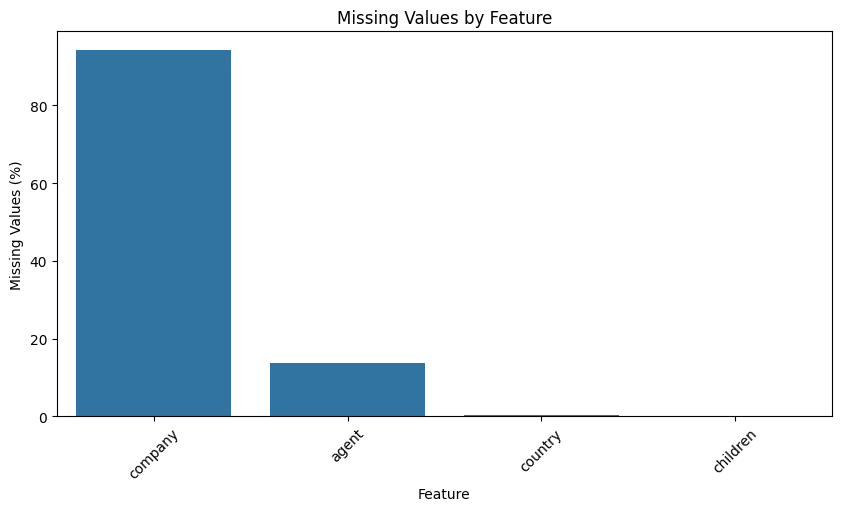

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Percentage"]
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)

plt.show()

#### Missing Value Findings

The missing-value analysis identified missing observations in four features: `company`, `agent`, `country`, and `children`.

The `company` feature has the highest proportion of missing values, with approximately 94.31% of records missing. The `agent` feature also contains a substantial proportion of missing values at approximately 13.69%. In contrast, `country` has only about 0.41% missing values, while `children` has only four missing observations.

The high proportion of missing values in `company` and `agent` may reflect the absence of a recorded company or booking agent rather than necessarily indicating data-entry errors. Therefore, these columns will be investigated further before a cleaning decision is made. The small number of missing values in `country` and `children` will also be examined before selecting an appropriate treatment.

### 9. Duplicate Detection



Duplicate records can distort statistical analysis and lead to biased results if the same booking is represented multiple times. The dataset will therefore be examined for completely duplicated rows before deciding whether any records should be removed.

In [17]:
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(31994)

Duplicate Percentage

In [18]:
duplicate_percentage = (duplicate_count / len(df)) * 100
print(f"Duplicate Rows: {duplicate_count}")
print(f"Percentage: {duplicate_percentage:.2f}%")

Duplicate Rows: 31994
Percentage: 26.80%


Inspecting Duplicate Rows

In [19]:
duplicates = df[df.duplicated()]
duplicates.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
219,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,No Deposit,NaN,110.0,0,Transient,104.72,0,1,Canceled,2015-07-08
256,Resort Hotel,0,91,2015,July,28,10,0,2,2,...,No Deposit,240.0,NaN,0,Transient,73.80,0,1,Check-Out,2015-07-12
261,Resort Hotel,0,30,2015,July,28,10,2,2,2,...,No Deposit,NaN,NaN,0,Transient-Party,197.00,0,1,Check-Out,2015-07-14
353,Resort Hotel,0,98,2015,July,29,13,1,1,2,...,No Deposit,240.0,NaN,0,Transient-Party,82.00,0,3,Check-Out,2015-07-15
372,Resort Hotel,0,40,2015,July,29,13,1,4,2,...,No Deposit,250.0,NaN,0,Transient,120.00,0,2,Check-Out,2015-07-18


#### Duplicate Detection Findings

The dataset contains 31,994 duplicated records, representing approximately 26.8% of all observations. This is a substantial proportion and requires further investigation.

At this stage, duplicates have only been identified and inspected. No records have been removed yet. A final decision regarding duplicate treatment will be made during the data cleaning stage after evaluating whether the duplicated observations represent redundant records or valid repeated bookings.

### 10. Inconsistent Categories



Categorical variables may contain inconsistent, unexpected, or rare values that can affect analysis and modeling. The unique values and frequency distributions of categorical features will be examined to identify potential inconsistencies.

identifying the categorical columns

In [20]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

inspecting the categories and frequencies

In [21]:
for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(df[column].value_counts(dropna=False).head(10))


Column: hotel
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Column: arrival_date_month
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
Name: count, dtype: int64

Column: meal
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

Column: country
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

Column: market_segment
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

Column: distribution_channel
distribution_channel
TA/TO        97870
Direct

Investigating the undefined values to know whether these Undefined values occur in otherwise normal records.

In [22]:
undefined_rows = df[
    (df["meal"] == "Undefined") |
    (df["market_segment"] == "Undefined") |
    (df["distribution_channel"] == "Undefined")
]

undefined_rows[
    ["hotel", "meal", "market_segment", "distribution_channel",
     "is_canceled", "adults", "children", "babies"]
].head(20)

,hotel,meal,market_segment,distribution_channel,is_canceled,adults,children,babies
3106,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3107,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3108,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3110,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3111,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3112,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3113,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3114,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,1,0.0,0
3115,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0
3116,Resort Hotel,Undefined,Offline TA/TO,TA/TO,0,2,0.0,0


In [23]:
for column in ["meal", "market_segment", "distribution_channel"]:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


meal
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

market_segment
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64


#### Inconsistent Category Findings

The categorical variables were examined for unexpected, inconsistent, or rare values. Most categorical features contained plausible and consistently formatted categories. However, the value `Undefined` was identified in the `meal`, `market_segment`, and `distribution_channel` features.

The `meal` feature contains 1,169 `Undefined` observations, while `market_segment` and `distribution_channel` contain 2 and 5 `Undefined` observations, respectively. These values were investigated based on their frequency and occurrence. Their final treatment will be determined during the data-cleaning stage.

Rare room-type categories were also observed, but rarity alone was not considered sufficient evidence for removal. These categories will therefore be retained unless further investigation identifies a specific data-quality issue.

### 11. Data Type Issues



The data types of the dataset variables are reviewed to determine whether the stored data types appropriately represent their analytical meaning. Particular attention is given to date fields, identifier fields, and numerical variables containing missing values. Any necessary type conversions will be performed during the data-cleaning stage and will be justified based on the role of each feature.

In [24]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


Investigating the date column

In [25]:
df["reservation_status_date"].head(10)

,reservation_status_date
0,2015-07-01
1,2015-07-01
2,2015-07-02
3,2015-07-02
4,2015-07-03
5,2015-07-03
6,2015-07-03
7,2015-07-03
8,2015-05-06
9,2015-04-22


In [26]:
df["reservation_status_date"].sample(10, random_state=42)

,reservation_status_date
30946,2016-12-09
40207,2015-07-16
103708,2016-12-30
85144,2016-03-10
109991,2017-04-20
110622,2017-04-30
47790,2016-02-26
44992,2015-10-18
30528,2016-11-26
16886,2015-09-16


Investigating agent and company


In [27]:
print("Agent:")
print(df["agent"].head(10))

print("\nCompany:")
print(df["company"].head(10))

Agent:
0      NaN
1      NaN
2      NaN
3    304.0
4    240.0
5    240.0
6      NaN
7    303.0
8    240.0
9     15.0
Name: agent, dtype: float64

Company:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: company, dtype: float64


This will help us distinguish numeric measurements from numeric-looking identifiers.

In [28]:
print("Agent unique values:", df["agent"].nunique(dropna=True))
print("Company unique values:", df["company"].nunique(dropna=True))

Agent unique values: 333
Company unique values: 352


Investigating children

In [29]:
df["children"].value_counts(dropna=False).sort_index()

,count
children,
0.0,110796
1.0,4861
2.0,3652
3.0,76
10.0,1
NaN,4


#### Data Type Findings

The data type investigation identified several variables whose stored data types require attention.

The `reservation_status_date` feature is stored as an `object` but contains date-formatted values, indicating that it should be converted to a datetime type during data cleaning.

The `agent` and `company` features are stored as `float64` because they contain missing values, but their values represent identifiers rather than continuous measurements. They will therefore be treated as identifier/categorical features during subsequent analysis rather than as numerical measurements.

The `children` feature is stored as `float64` and contains four missing values. The presence of missing values explains the use of a floating-point data type. The feature also contains a value of 10 in one observation, which will be investigated later as a potential outlier rather than being treated as a data-type issue.

### 12. Unnecessary Columns


The dataset will be reviewed for variables that may be redundant, unsuitable, or unnecessary for the intended analysis. Columns will not be removed solely because they contain missing values or appear to have limited variation. Any column removal will be based on its analytical relevance, redundancy, data quality, and potential contribution to the objectives of the analysis.

Listing every column

In [30]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

Checking how much information each column contains

In [31]:
column_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(dropna=True),
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100
})

column_summary

,Data Type,Unique Values,Missing Values,Missing %
hotel,object,2,0,0.000000
is_canceled,int64,2,0,0.000000
lead_time,int64,479,0,0.000000
arrival_date_year,int64,3,0,0.000000
arrival_date_month,object,12,0,0.000000
arrival_date_week_number,int64,53,0,0.000000
arrival_date_day_of_month,int64,31,0,0.000000
stays_in_weekend_nights,int64,17,0,0.000000
stays_in_week_nights,int64,35,0,0.000000
adults,int64,14,0,0.000000


Look specifically at identifier-like columns

In [32]:
df[["agent", "company"]].nunique(dropna=True)

,0
agent,333
company,352


#### Unnecessary Column Findings

The dataset contains 32 features, and each feature was reviewed based on its analytical relevance, uniqueness, missingness, and role in the booking data.

The `agent` and `company` features contain 333 and 352 unique identifiers respectively. Although these features contain a substantial number of missing values, they represent booking-agent and company identifiers rather than continuous numerical measurements. Therefore, they will not be removed solely because of their missingness and will be considered separately during the data-cleaning and feature-selection stages.

The `reservation_status_date` feature contains date information that may be useful for temporal analysis, so it will be retained and converted to an appropriate datetime format during cleaning.

Other booking, guest, stay, room, and reservation features provide potentially relevant information for exploratory analysis and will therefore be retained at this stage.

No columns are removed during the data-quality investigation because there is currently insufficient evidence to classify any feature as completely unnecessary. Any later feature removal will be justified based on analytical requirements, redundancy, or modeling considerations.


# **Exploratory Data Analysis (EDA)**


### 13. Univariate Analysis



Univariate analysis examines individual variables independently to understand their distributions, frequencies, central tendencies, and potential unusual values. Numerical and categorical features will be analyzed using appropriate statistical summaries and visualizations.

Numerical Columns

In [33]:
numerical_columns = df.select_dtypes(include=np.number).columns
numerical_columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

Categorical Columns

In [34]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

####13.1 Numerical Variable Distributions



The numerical and count-based variables are analyzed individually to understand their distributions, central tendencies, spread, skewness, and potential unusual observations. Identifier and binary variables are analyzed separately because their numerical storage format does not represent continuous measurements.

In [35]:
numeric_analysis_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

analyzing the first variable

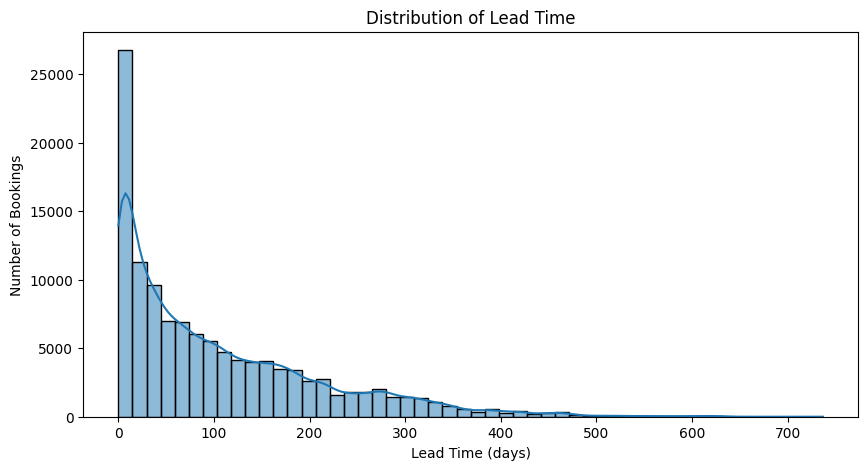

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(df["lead_time"], bins=50, kde=True)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Bookings")

plt.show()

##### Lead Time Distribution – Findings

The `lead_time` variable is strongly right-skewed. Most hotel bookings are made relatively close to the arrival date, resulting in a high concentration of observations at lower lead-time values. The frequency of bookings decreases as the lead time increases, producing a long right tail that extends beyond 700 days.

The distribution indicates that advance booking behavior is not uniform across observations. The extreme values in the right tail will be considered during the later outlier investigation rather than being removed at this stage.

####13.2 Weekend Stay Nights


The `stays_in_weekend_nights` variable represents the number of weekend nights included in each booking. Its distribution is examined to understand the typical length of weekend stays and identify unusual values.


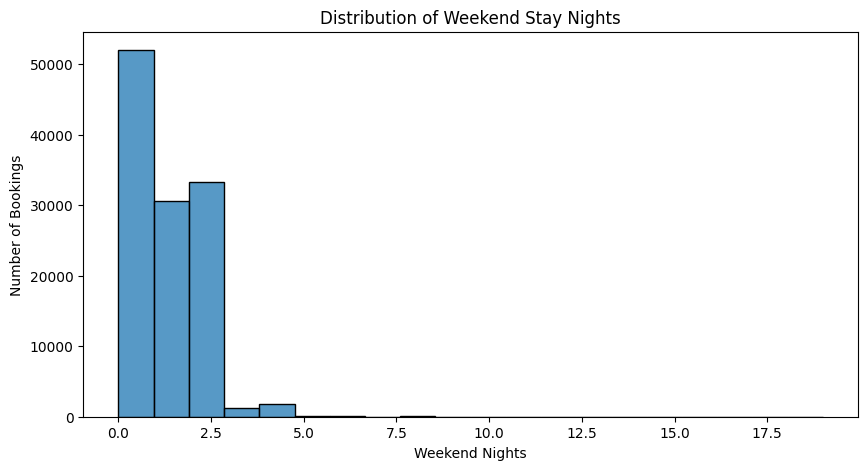

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(df["stays_in_weekend_nights"], bins=20)

plt.title("Distribution of Weekend Stay Nights")
plt.xlabel("Weekend Nights")
plt.ylabel("Number of Bookings")

plt.show()

##### Weekend Stay Nights – Findings

The `stays_in_weekend_nights` variable is a discrete count variable with a high concentration of bookings containing zero weekend nights. One- and two-night weekend stays are also common, while the frequency decreases considerably for longer weekend stays.

The distribution is right-skewed, with a small number of observations representing relatively long weekend stays. These unusual values will be considered during the later outlier investigation rather than being removed during EDA.

#### 13.3 Week Stay Nights



The `stays_in_week_nights` variable represents the number of weekday nights included in each booking. Its distribution is examined to understand the typical length of weekday stays and identify potentially unusual values.

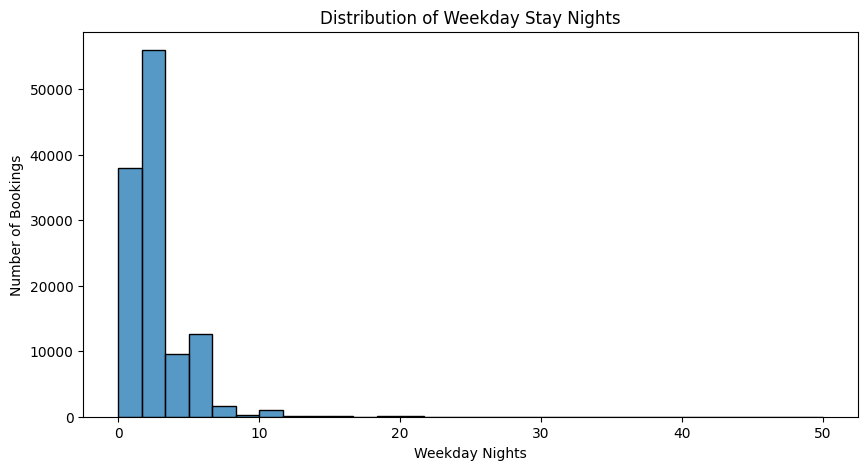

In [38]:
plt.figure(figsize=(10, 5))

sns.histplot(df["stays_in_week_nights"], bins=30)

plt.title("Distribution of Weekday Stay Nights")
plt.xlabel("Weekday Nights")
plt.ylabel("Number of Bookings")

plt.show()

##### Weekday Stay Nights – Findings

The `stays_in_week_nights` variable is concentrated around shorter stays, with most bookings containing approximately 0 to 4 weekday nights. The highest frequency occurs among bookings with one to two weekday nights, while the number of observations decreases substantially as the length of the weekday stay increases.

The distribution is strongly right-skewed, with a small number of bookings representing considerably longer weekday stays. These extreme observations will be examined during the later outlier investigation rather than being removed at this stage.

#### 13.4 Adults per Booking



The `adults` variable represents the number of adults included in each hotel booking. Its distribution is examined to understand the typical booking party size and identify unusual observations.

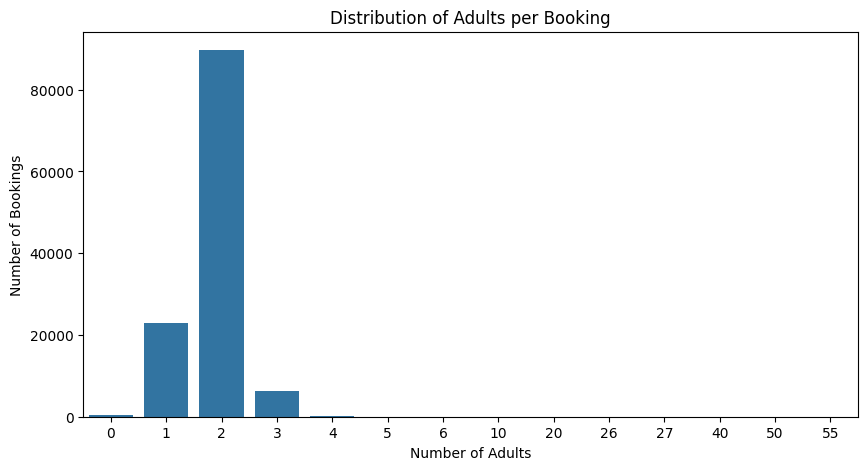

In [39]:
plt.figure(figsize=(10, 5))

sns.countplot(x=df["adults"])

plt.title("Distribution of Adults per Booking")
plt.xlabel("Number of Adults")
plt.ylabel("Number of Bookings")

plt.show()

##### Adults per Booking – Findings

The `adults` variable is highly concentrated around typical booking sizes. Bookings containing two adults are by far the most common, followed by bookings containing one adult. Bookings with three or more adults occur much less frequently.

A small number of observations contain unusually large numbers of adults, including values substantially higher than the typical booking size. These observations may represent outliers or potential data-quality issues and will be investigated during the later outlier analysis.

The variable therefore shows a strong concentration at lower values with a long right tail.

#### 13.5 Children per Booking



The `children` variable represents the number of children included in each booking. Its distribution is examined to understand the typical number of children per booking and to identify unusual values.

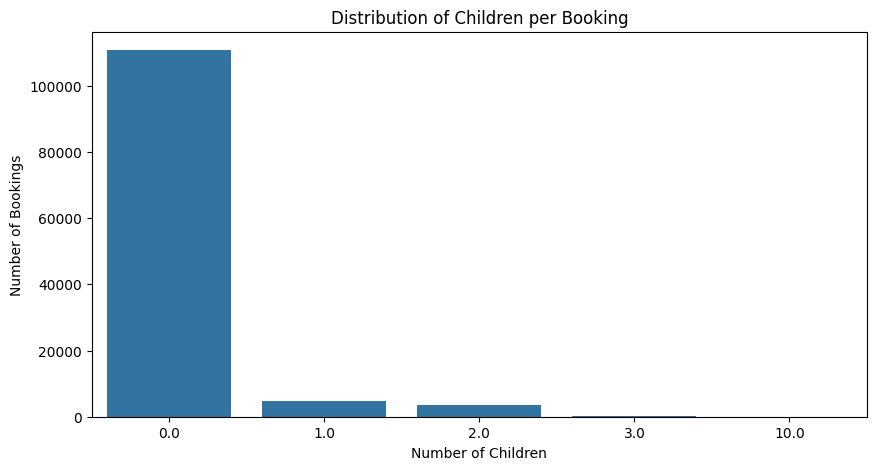

In [40]:
plt.figure(figsize=(10, 5))

sns.countplot(x=df["children"])

plt.title("Distribution of Children per Booking")
plt.xlabel("Number of Children")
plt.ylabel("Number of Bookings")

plt.show()

##### Children per Booking – Findings

The `children` variable is highly concentrated at zero, indicating that the vast majority of bookings do not include children. Bookings with one or two children occur less frequently, while bookings with three or more children are relatively rare.

A small number of observations contain unusually high values, including bookings with 10 children. These observations will be investigated later as potential outliers or data-quality issues.

The variable also contains four missing observations, which were identified during the missing-value analysis. These missing values will be addressed during the data-cleaning stage.

#### 13.6 Babies per Booking



The `babies` variable represents the number of babies included in each booking. Its distribution is examined to understand how frequently bookings include babies and to identify unusual values.

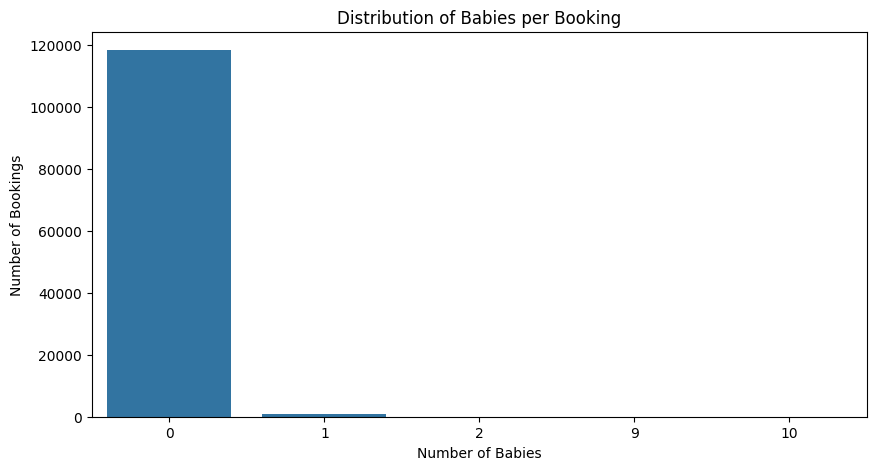

In [41]:
plt.figure(figsize=(10, 5))

sns.countplot(x=df["babies"])

plt.title("Distribution of Babies per Booking")
plt.xlabel("Number of Babies")
plt.ylabel("Number of Bookings")

plt.show()

#### Babies per Booking – Findings

The `babies` variable is highly concentrated at zero, indicating that the vast majority of bookings do not include babies. Bookings with one or two babies are very uncommon.

A small number of observations contain unusually high values, including bookings with 9 and 10 babies. These observations are substantially different from the typical booking pattern and will be investigated later as potential outliers or data-quality issues.

Overall, the distribution is strongly right-skewed and dominated by observations with zero babies.

#### 13.7 Booking Cancellation Status



The `is_canceled` variable indicates whether a hotel booking was canceled. A value of 0 represents a booking that was not canceled, while a value of 1 represents a canceled booking. The distribution is examined to understand the proportion of canceled and non-canceled bookings.

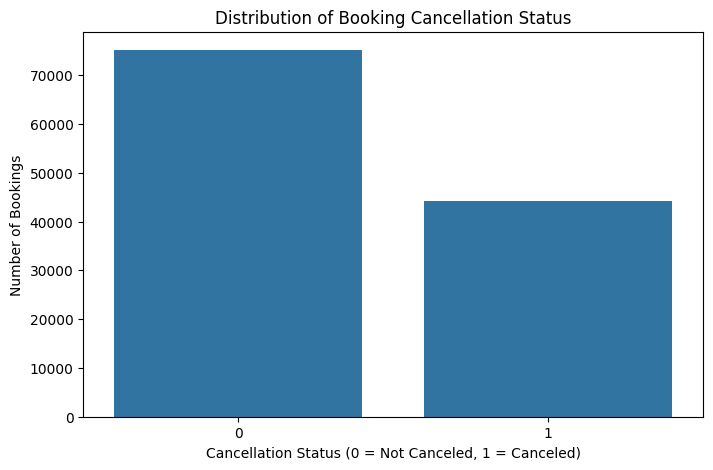

In [42]:
plt.figure(figsize=(8, 5))

sns.countplot(x=df["is_canceled"])

plt.title("Distribution of Booking Cancellation Status")
plt.xlabel("Cancellation Status (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Number of Bookings")

plt.show()

#####Booking Cancellation Status – Findings

The is_canceled variable contains two categories: 0 represents bookings that were not canceled, while 1 represents canceled bookings. The distribution shows that non-canceled bookings are more common than canceled bookings.

Approximately 62.9% of bookings were not canceled, while approximately 37.1% were canceled. Therefore, the target variable is somewhat imbalanced, with non-canceled bookings representing the majority class.

However, canceled bookings still account for a substantial proportion of the dataset. This class distribution should be considered during later predictive modeling and evaluation.

### 14. Categorical Analysis


#### 14.1 Hotel Type

The hotel variable identifies whether the booking was made at a City Hotel or Resort Hotel. Its distribution is examined to determine which hotel type receives more bookings.

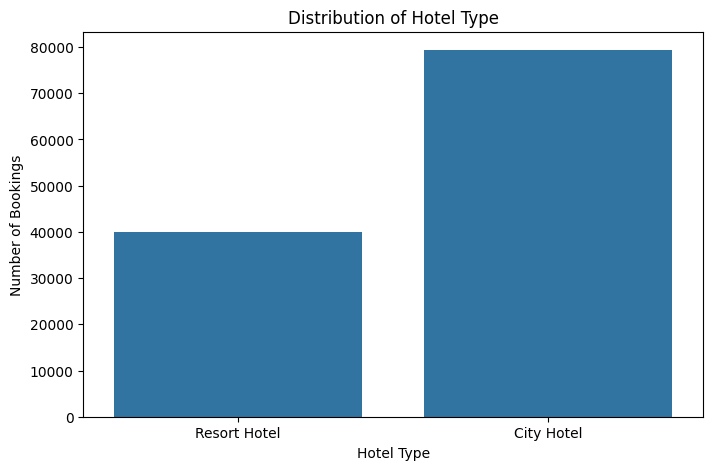

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="hotel")

plt.title("Distribution of Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

#####Hotel Type – Findings

The distribution shows that City Hotel bookings are considerably more common than Resort Hotel bookings. City Hotels account for approximately two-thirds of all observations, while Resort Hotels account for roughly one-third.

This indicates that the dataset contains substantially more bookings from City Hotels than Resort Hotels.

####14.2 Arrival Month



The arrival_date_month variable represents the month in which guests are scheduled to arrive.



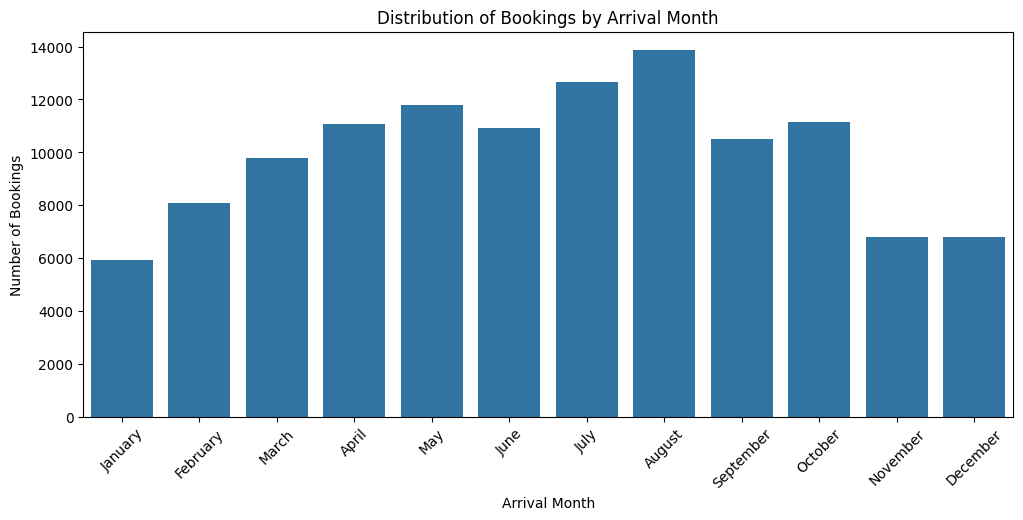

In [44]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="arrival_date_month",
    order=[
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ]
)

plt.title("Distribution of Bookings by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()


#####Arrival Month – Findings

The distribution of bookings varies across arrival months. August has the highest number of bookings, followed by July and May. In contrast, November has one of the lowest booking frequencies.

The variation suggests that booking demand is influenced by seasonality, with certain months experiencing substantially higher booking activity than others.

####14.3 Meal Type


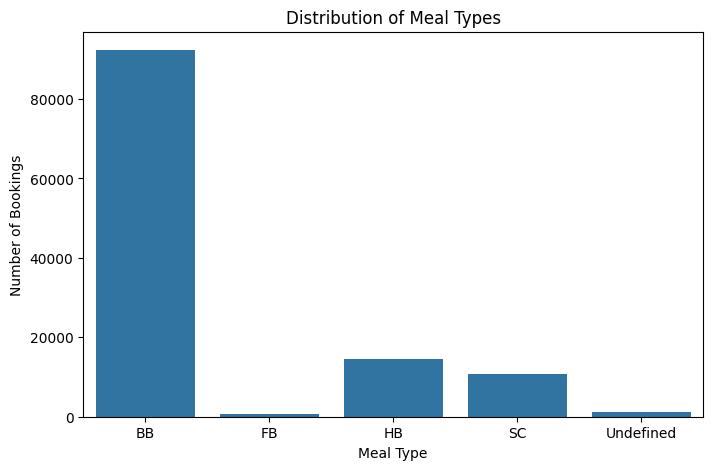

In [45]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="meal")

plt.title("Distribution of Meal Types")
plt.xlabel("Meal Type")
plt.ylabel("Number of Bookings")

plt.show()

#####Meal Type – Findings

The meal variable is strongly dominated by the BB category, representing Bed & Breakfast arrangements. HB and SC are considerably less common, while FB represents only a small proportion of bookings.

The Undefined category is also present and was previously identified as a potential data-quality issue. It will be investigated during the data-cleaning stage.

####14.4 Market Segment

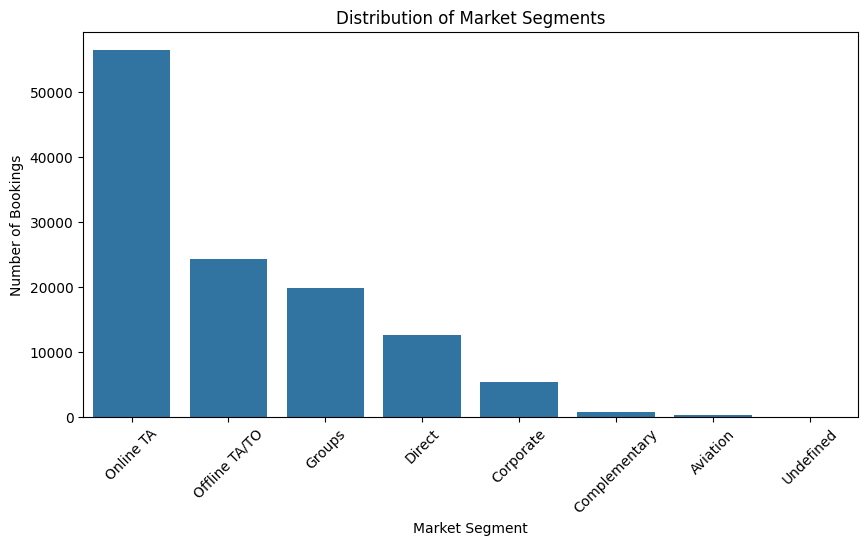

In [46]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="market_segment",
    order=df["market_segment"].value_counts().index
)

plt.title("Distribution of Market Segments")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

#####Market Segment – Findings

The Online TA market segment has the highest number of bookings by a substantial margin. Offline TA/TO and Groups are the next most common segments, while Corporate, Complementary, and Aviation bookings occur less frequently.

Two observations were recorded as Undefined. These values are extremely rare and will be investigated during data cleaning.



####14.5 Distribution Channel

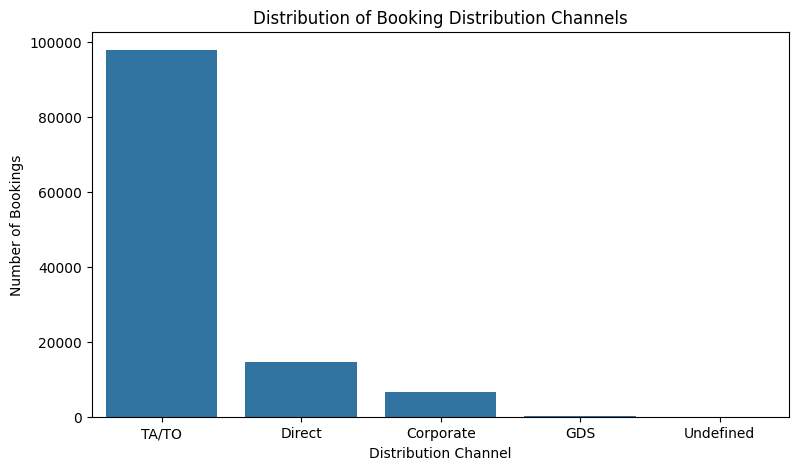

In [47]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="distribution_channel",
    order=df["distribution_channel"].value_counts().index
)

plt.title("Distribution of Booking Distribution Channels")
plt.xlabel("Distribution Channel")
plt.ylabel("Number of Bookings")

plt.show()

#####Distribution Channel – Findings

The TA/TO channel accounts for the overwhelming majority of bookings, followed by Direct and Corporate channels. GDS bookings represent only a very small proportion of the dataset.

Five observations contain the Undefined category. Because these observations are extremely rare, they will be investigated during data cleaning rather than removed solely because of their low frequency.


####14.6 Deposit Type

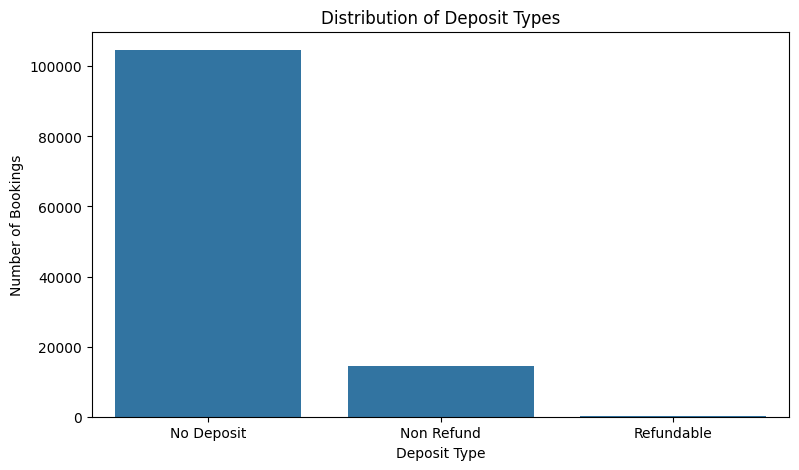

In [48]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="deposit_type",
    order=df["deposit_type"].value_counts().index
)

plt.title("Distribution of Deposit Types")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")

plt.show()

#####Deposit Type – Findings

The deposit_type variable is heavily dominated by No Deposit bookings. Non Refund bookings represent a considerably smaller proportion, while Refundable bookings are extremely rare.

This indicates that most bookings in the dataset were made without requiring an upfront deposit.

####14.7 Customer Type

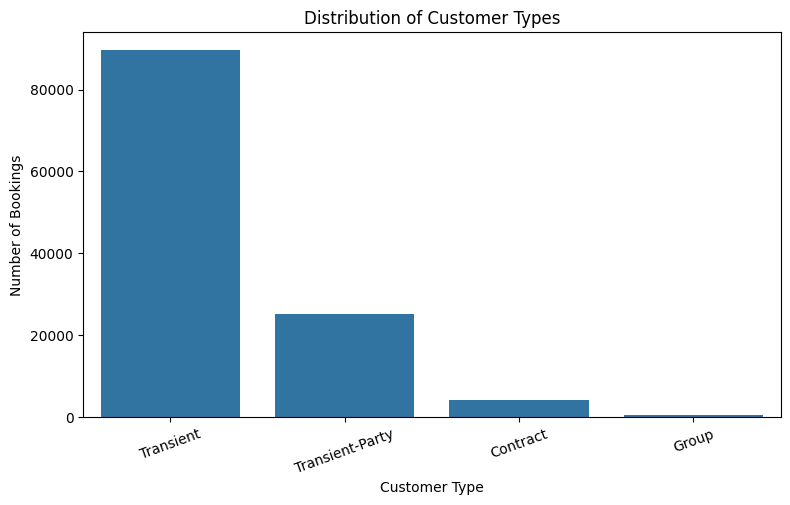

In [49]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="customer_type",
    order=df["customer_type"].value_counts().index
)

plt.title("Distribution of Customer Types")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)

plt.show()

#####Customer Type – Findings

The dataset is dominated by Transient customers, followed by Transient-Party customers. Contract customers represent a much smaller proportion, while Group customers are relatively rare.

This indicates that individual or transient bookings make up the majority of the dataset.

####14.8 Reservation Status

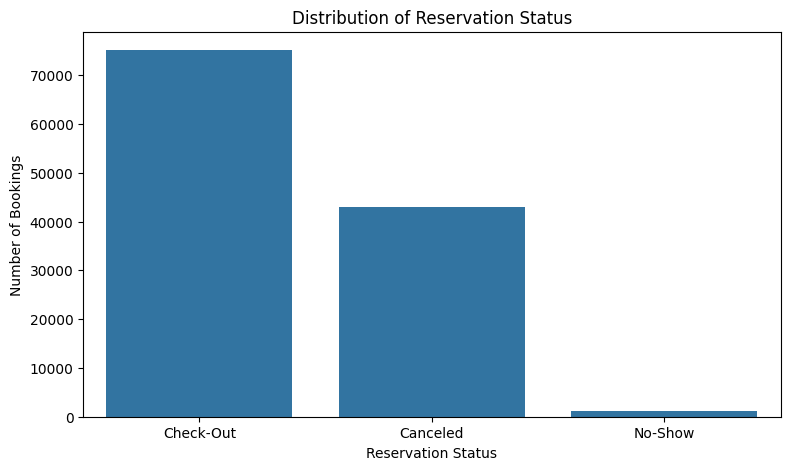

In [50]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="reservation_status",
    order=df["reservation_status"].value_counts().index
)

plt.title("Distribution of Reservation Status")
plt.xlabel("Reservation Status")
plt.ylabel("Number of Bookings")

plt.show()

#####Reservation Status – Findings

The majority of bookings have a Check-Out status, indicating that most reservations were completed. Canceled bookings form the second-largest category, while No-Show bookings represent a very small proportion of observations.

The relatively large number of canceled bookings is consistent with the cancellation distribution examined earlier using is_canceled.

####14.9 Country — Top 10

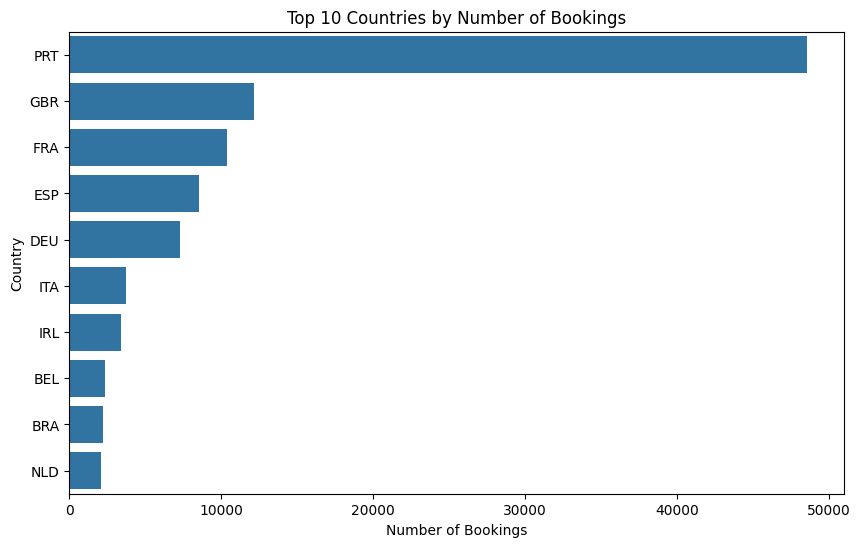

In [51]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")

plt.show()

#####Country – Findings

The distribution of bookings by country is highly concentrated among a small number of countries. Portugal (PRT) has by far the highest number of bookings, followed by the United Kingdom (GBR), France (FRA), Spain (ESP), and Germany (DEU).

The remaining countries in the top 10 account for substantially smaller numbers of bookings. This indicates that the dataset is dominated by bookings from a relatively limited group of countries.

####14.10 Reserved Room Type






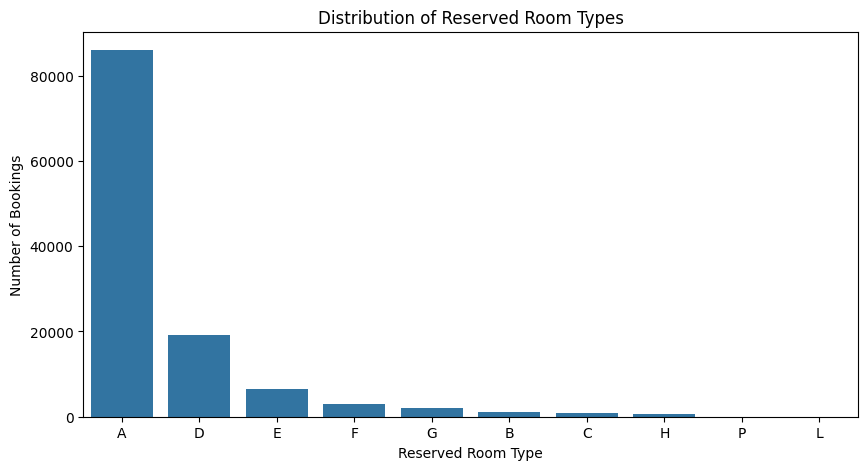

In [52]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="reserved_room_type",
    order=df["reserved_room_type"].value_counts().index
)

plt.title("Distribution of Reserved Room Types")
plt.xlabel("Reserved Room Type")
plt.ylabel("Number of Bookings")

plt.show()

#####Findings

The A room type is by far the most frequently reserved room type, followed by D and E. The remaining room types occur considerably less frequently.

Several room types have very low frequencies. However, these rare categories should not be removed solely because they occur infrequently, as they may represent legitimate room types.

####14.11 Assigned Room Type

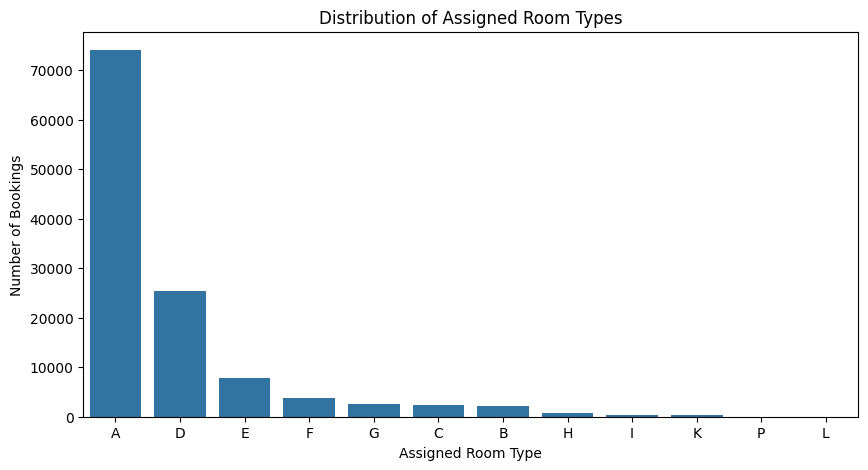

In [53]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="assigned_room_type",
    order=df["assigned_room_type"].value_counts().index
)

plt.title("Distribution of Assigned Room Types")
plt.xlabel("Assigned Room Type")
plt.ylabel("Number of Bookings")

plt.show()

#####Findings

The assigned room distribution is also dominated by Room Type A, followed by D and E. However, the frequencies differ from those observed for reserved room types.

This difference suggests that some bookings may have been assigned a room type different from the type originally reserved. This relationship will be examined more closely during bivariate analysis.

### 15. Numerical Distributions




Numerical distribution analysis is performed to examine the central tendency, spread, skewness, and potential extreme values of the numerical variables. Summary statistics, skewness measures, and boxplots are used to assess the overall distribution of the numerical features. Potential extreme observations are not removed at this stage because they will be investigated separately using formal outlier detection techniques

####15.1 Summary Statistics

In [54]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


for meaningful continuous/count numerical distributions , I went for:

In [55]:
distribution_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

df[distribution_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.00,0.000,0.0,72.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0


####15.2 Skewness Analysis

In [56]:
skewness = df[distribution_columns].skew().sort_values(ascending=False)

skewness_df = pd.DataFrame(skewness, columns=["Skewness"])

skewness_df

,Skewness
babies,24.646545
previous_cancellations,24.458049
previous_bookings_not_canceled,23.539800
adults,18.317805
days_in_waiting_list,11.944353
adr,10.530214
booking_changes,6.000270
required_car_parking_spaces,4.163233
children,4.112590
stays_in_week_nights,2.862249


####15.3 Boxplots

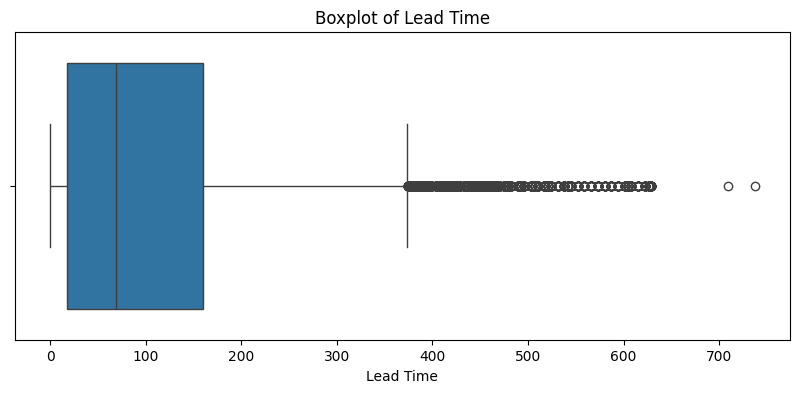

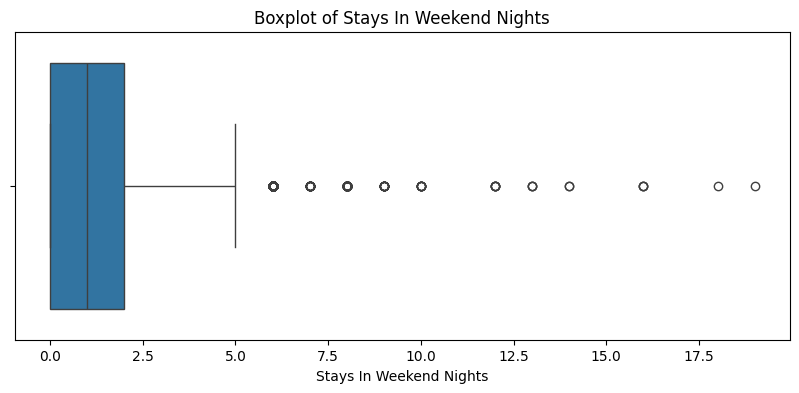

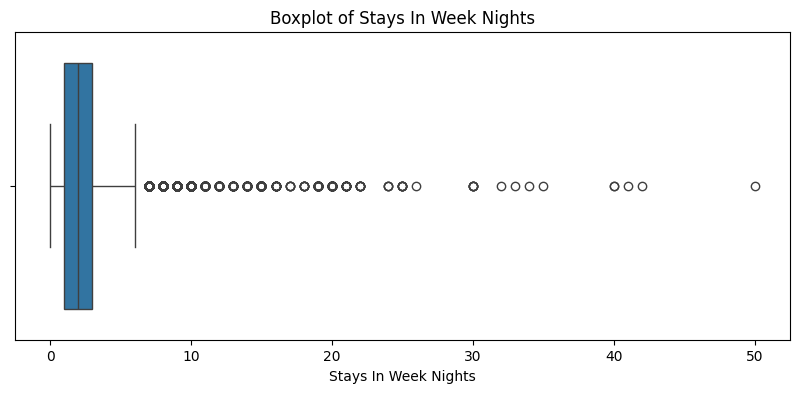

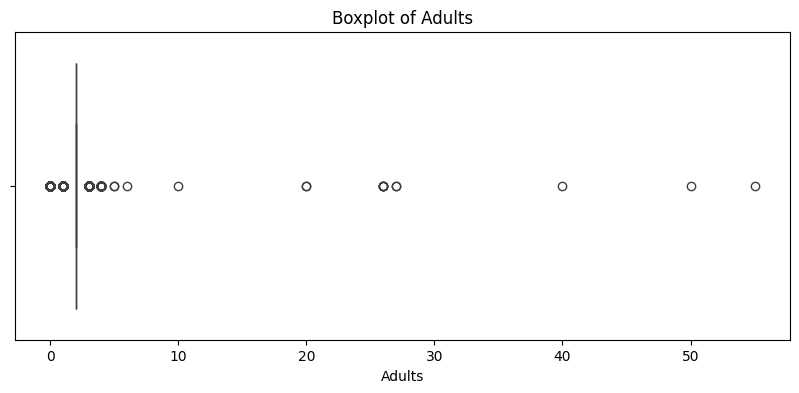

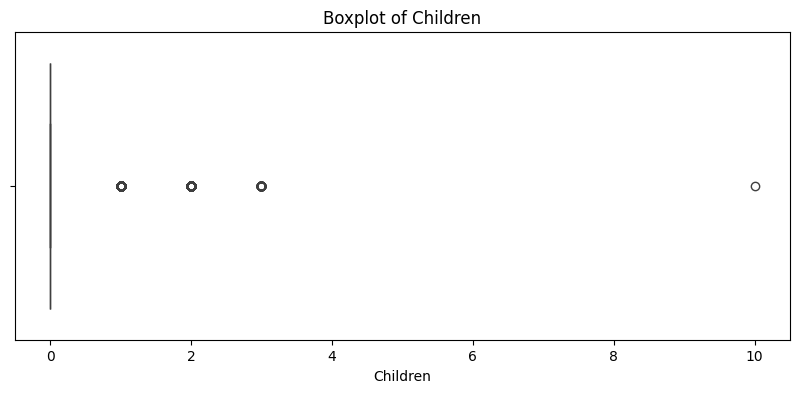

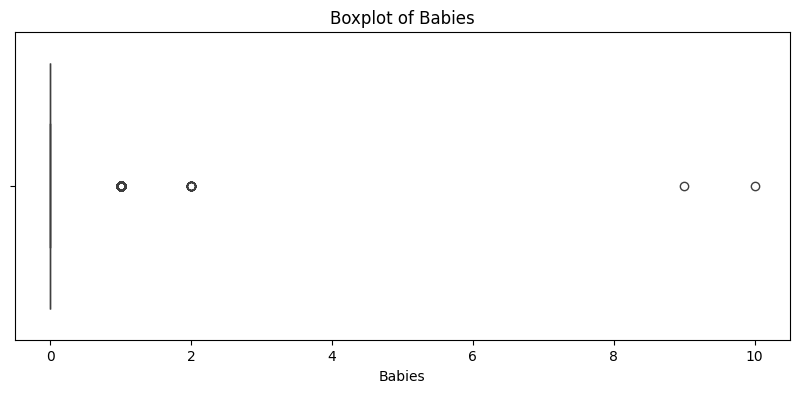

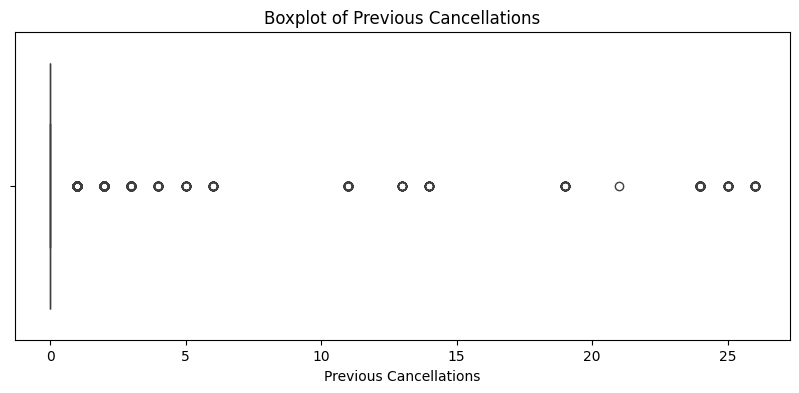

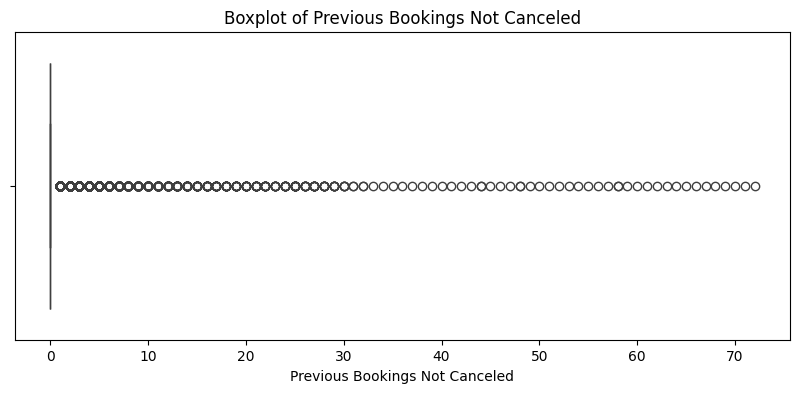

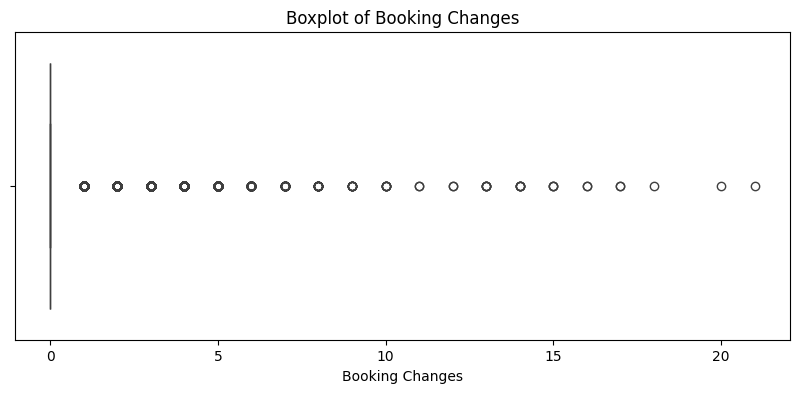

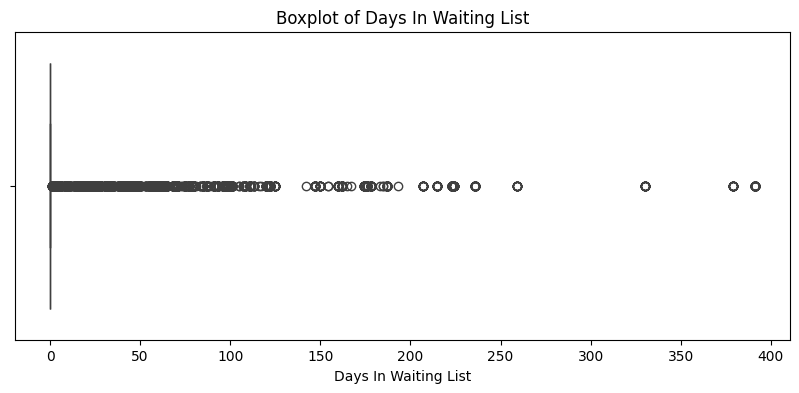

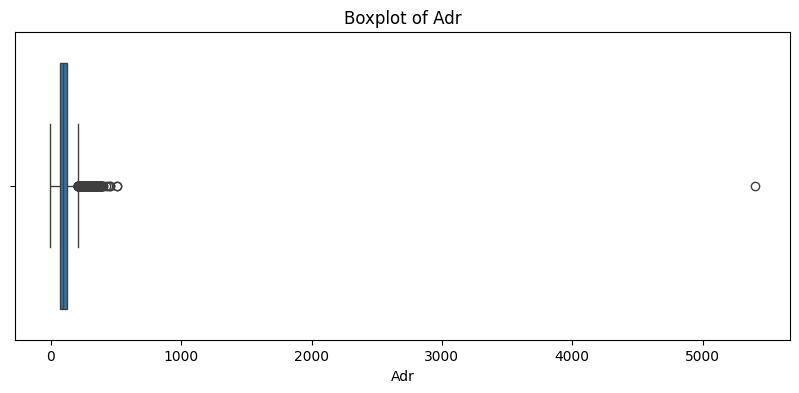

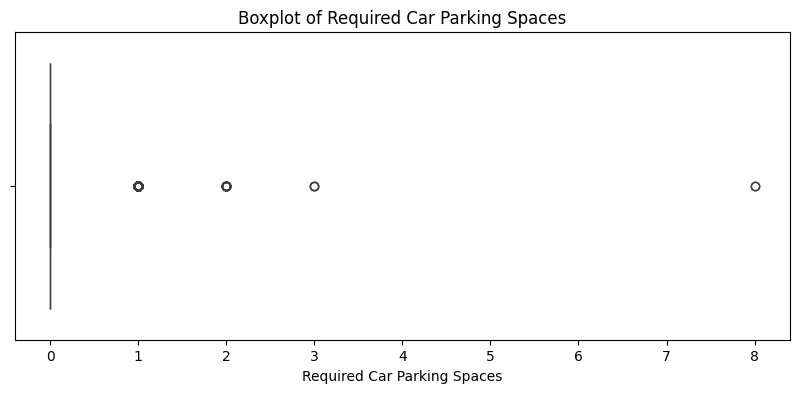

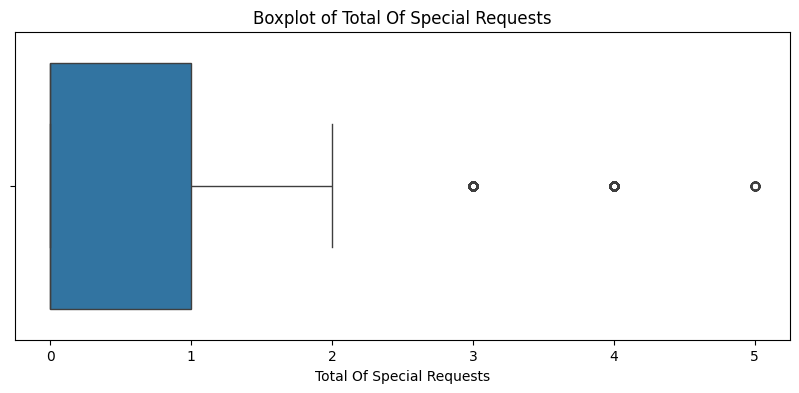

In [57]:
for column in distribution_columns:
    plt.figure(figsize=(10, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column.replace('_', ' ').title()}")
    plt.xlabel(column.replace("_", " ").title())

    plt.show()

####15.4 Numerical Distribution Findings

##### Numerical Distribution – Findings

The numerical variables exhibit different levels of variability and distributional shape. Several count-based variables, including stay duration, number of children, number of babies, previous cancellations, and special requests, are concentrated around relatively small values and show positive skewness.

The `lead_time` variable has a strong right-skewed distribution, indicating that most bookings are made relatively close to the arrival date, while a smaller number of bookings are made substantially further in advance.

The `adr` variable shows greater variability compared with most count-based variables, indicating differences in the daily room rates associated with bookings.

The boxplots reveal potential extreme observations across several numerical variables. These observations are not considered errors solely because they appear outside the main distribution. They will be investigated using formal outlier detection techniques in a later stage of the analysis.

Overall, the numerical variables demonstrate substantial differences in scale, spread, and skewness. These characteristics should be considered when performing further statistical and predictive analysis.

### 16. Bivariate Analysis




Bivariate analysis is used to examine relationships between pairs of variables and identify patterns that may provide meaningful insights into hotel booking behavior. Numerical and categorical variables are compared using appropriate visualizations to investigate factors such as cancellation behavior, booking lead time, stay duration, room rates, and hotel characteristics.

The analysis focuses on relationships that are relevant to the business objectives of understanding booking patterns and cancellation behavior. Observed associations are interpreted as relationships rather than causal effects.

####16.1 Hotel Type vs Cancellation

To know: Do City Hotels and Resort Hotels have different cancellation patterns?

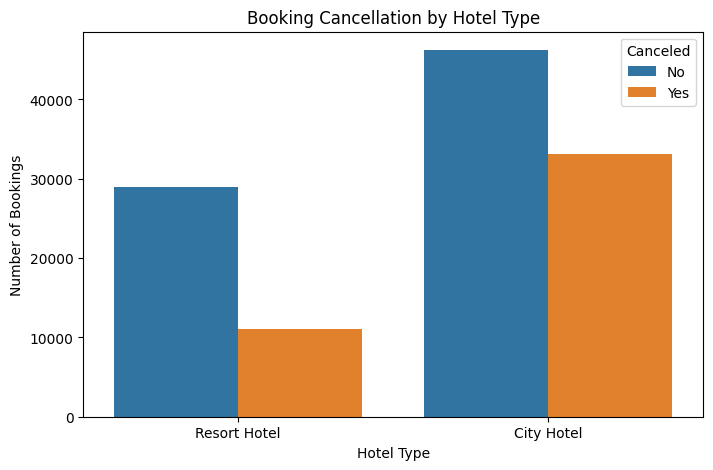

In [58]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.title("Booking Cancellation by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Canceled", labels=["No", "Yes"])

plt.show()

#####Findings

The cancellation rate is different between the two hotel types. City Hotels have a much higher number of canceled bookings compared with Resort Hotels.

For Resort Hotels, the number of bookings that were not canceled is higher than the number of canceled bookings. In contrast, City Hotels have more canceled bookings than non-canceled bookings.

This shows that City Hotel bookings are more likely to be canceled, while Resort Hotel bookings are more likely to be completed.

####16.2 Lead Time vs Cancellation

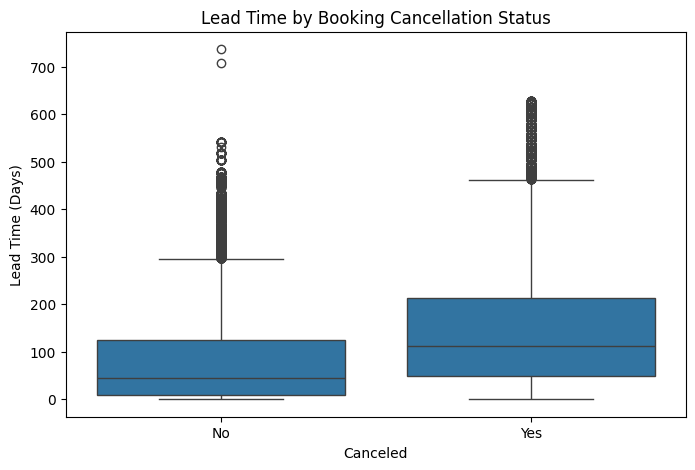

In [59]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time"
)

plt.title("Lead Time by Booking Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Lead Time (Days)")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

#####Findings

The boxplot shows that canceled bookings generally have a higher lead time than non-canceled bookings. In other words, customers who book further in advance appear more likely to cancel their bookings.

Non-canceled bookings usually have a lower lead time, while canceled bookings have a higher median and wider distribution.

Both groups contain some very high lead-time values, which appear as outliers. These values will be considered during the outlier analysis rather than being removed at this stage.

####16.3 Stay Duration vs Cancellation

In [60]:
df["total_stay_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

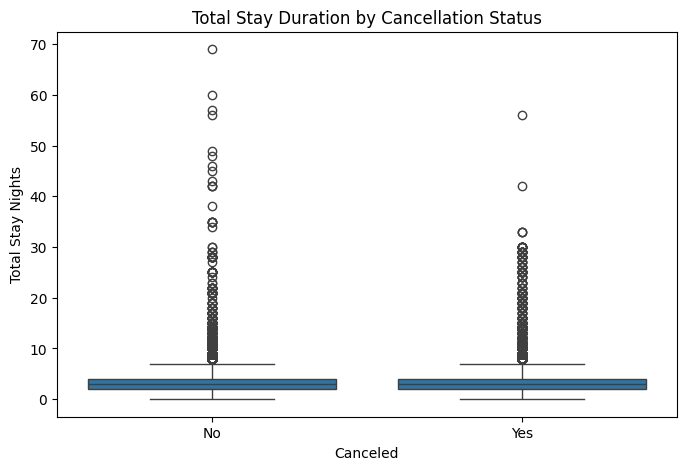

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="total_stay_nights"
)

plt.title("Total Stay Duration by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Total Stay Nights")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

#####Finding
The two groups have similar stay durations, with most bookings having only a few nights. However, there are many outliers with longer stays. Overall, total stay duration does not show a very large difference between canceled and non-canceled bookings.



####16.4 ADR vs Cancellation

To know: Does room price differ between canceled and non-canceled bookings?

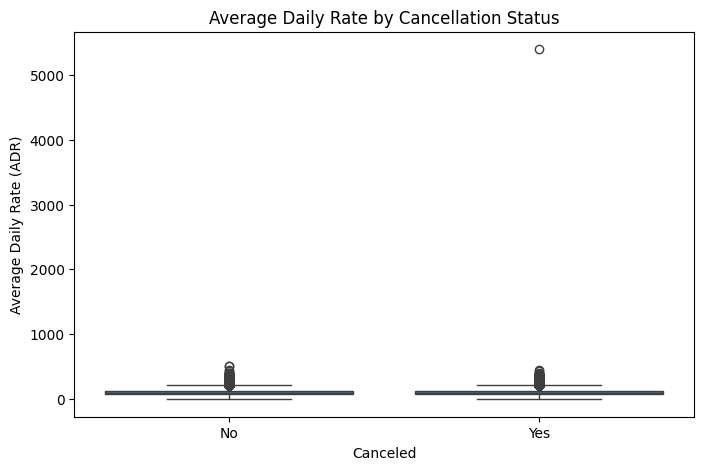

In [62]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="adr"
)

plt.title("Average Daily Rate by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Average Daily Rate (ADR)")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()


#####Finding
The plot shows that the normal daily room rates are similar for both groups. However, a few bookings have extremely high ADR values, especially among canceled bookings. These outliers can strongly affect the average, so the typical ADR does not appear to be very different between the two groups.



####16.5 Market Segment vs Cancellation

To know: Which market segments have higher cancellation proportions?

In [63]:
cancellation_by_segment = (
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

cancellation_by_segment

,is_canceled
market_segment,
Undefined,1.000000
Groups,0.610620
Online TA,0.367211
Offline TA/TO,0.343160
Aviation,0.219409
Corporate,0.187347
Direct,0.153419
Complementary,0.130552


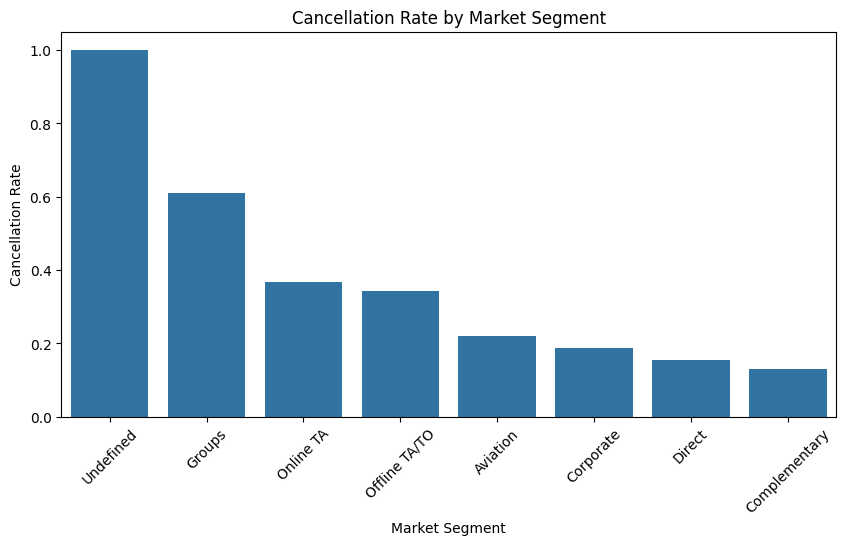

In [64]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=cancellation_by_segment.index,
    y=cancellation_by_segment.values
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate")

plt.xticks(rotation=45)

plt.show()

#####Finding
Cancellation rates vary a lot across market segments. Groups and Online TA show relatively high cancellation rates, while Direct, Corporate, and Complementary have lower rates. The Undefined category has a very high rate, but it should be interpreted carefully because it may contain fewer bookings.



####16.6 Customer Type vs Cancellation

In [65]:
cancellation_by_customer = (
    df.groupby("customer_type")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

cancellation_by_customer

,is_canceled
customer_type,
Transient,0.407463
Contract,0.309617
Transient-Party,0.254299
Group,0.102253


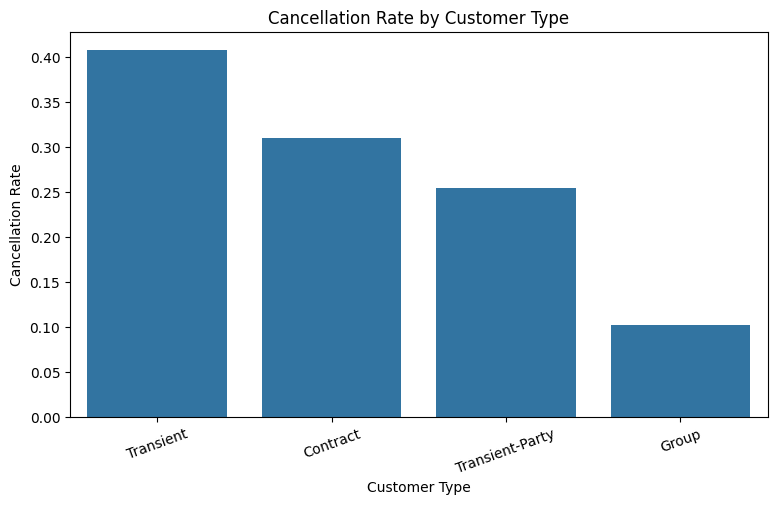

In [66]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=cancellation_by_customer.index,
    y=cancellation_by_customer.values
)

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate")

plt.xticks(rotation=20)

plt.show()

#####Finding
The plot shows a clear difference between customer types. Transient customers are more likely to cancel their bookings, while Group customers have the lowest cancellation rate. This suggests that customer type can be an important factor in understanding cancellations.


####16.7 Deposit Type vs Cancellation

To know: Does deposit type relate to cancellation behavior?

In [67]:
cancellation_by_deposit = (
    df.groupby("deposit_type")["is_canceled"]
      .mean()
      .sort_values(ascending=False)
)

cancellation_by_deposit

,is_canceled
deposit_type,
Non Refund,0.993624
No Deposit,0.283770
Refundable,0.222222


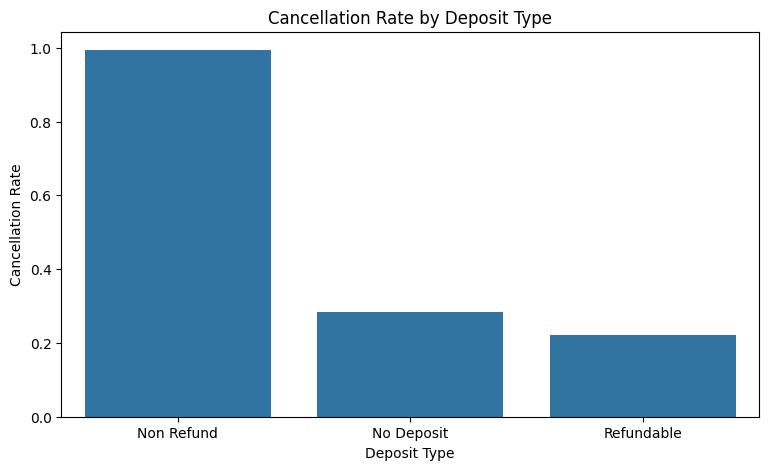

In [68]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=cancellation_by_deposit.index,
    y=cancellation_by_deposit.values
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate")

plt.show()

#####Findings
The deposit type shows a strong relationship with cancellation. Bookings with Non Refund deposits have the highest cancellation rate, while Refundable bookings have a much lower rate. This is an important finding because deposit policies may strongly affect booking behavior.


####16.8 Special Requests vs Cancellation

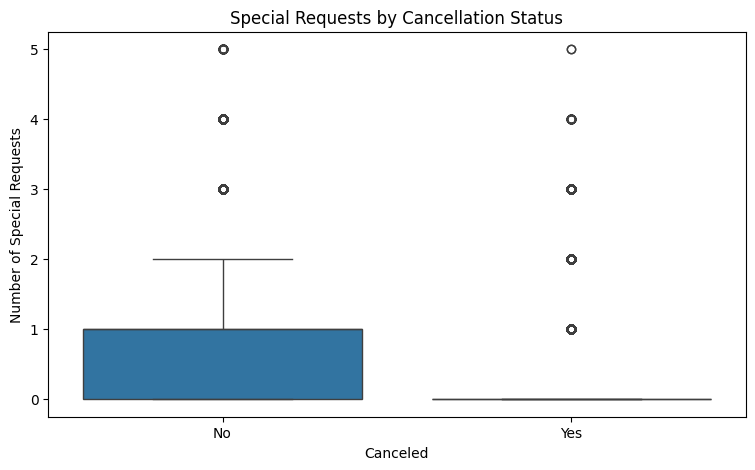

In [69]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="total_of_special_requests"
)

plt.title("Special Requests by Cancellation Status")
plt.xlabel("Canceled")
plt.ylabel("Number of Special Requests")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

#####Finding
Most customers do not make many special requests. Non-canceled bookings show a slightly wider range of requests, while canceled bookings are mostly concentrated at zero requests. This suggests that customers making special requests may be somewhat more likely to complete their bookings.

####16.9 Repeated Guest vs Cancellation

In [70]:
cancellation_by_repeat = (
    df.groupby("is_repeated_guest")["is_canceled"]
      .mean()
)

cancellation_by_repeat

,is_canceled
is_repeated_guest,
0,0.377851
1,0.144882


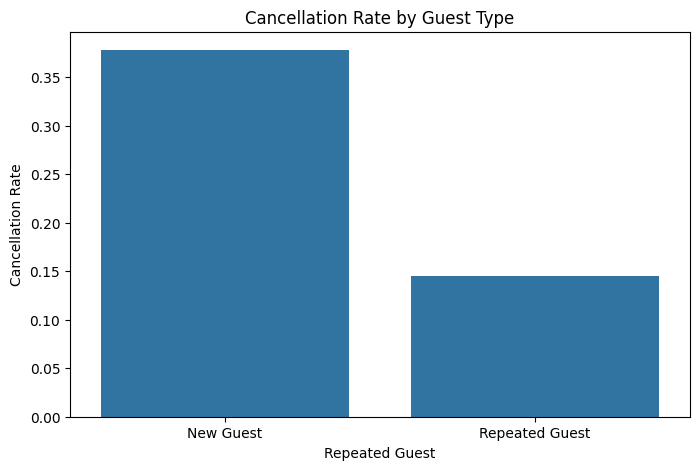

In [71]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cancellation_by_repeat.index,
    y=cancellation_by_repeat.values
)

plt.title("Cancellation Rate by Guest Type")
plt.xlabel("Repeated Guest")
plt.ylabel("Cancellation Rate")

plt.xticks([0, 1], ["New Guest", "Repeated Guest"])

plt.show()




#####Finding
The plot shows that new guests are more likely to cancel their bookings, with a cancellation rate of around 38%, compared with around 15% for repeated guests. This suggests that returning customers are generally more reliable.

####16.10 Reserved vs Assigned Room Type

To know: Are guests usually assigned the room type they originally reserved?

In [72]:
df["room_type_changed"] = (
    df["reserved_room_type"] != df["assigned_room_type"]
)

In [73]:
df["room_type_changed"].value_counts()

,count
room_type_changed,
False,104473
True,14917


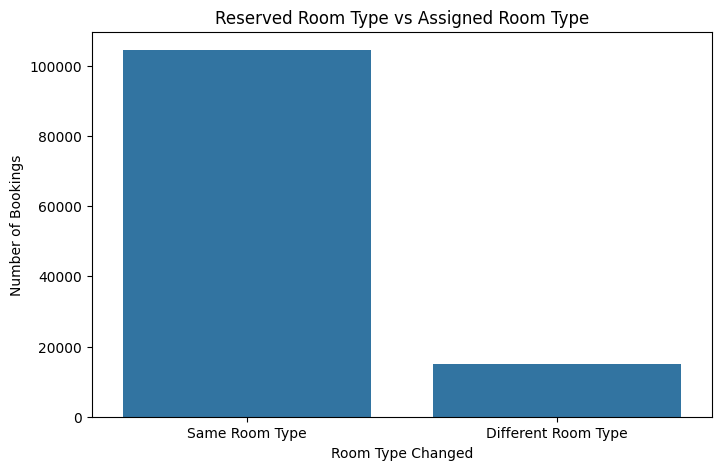

In [74]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="room_type_changed"
)

plt.title("Reserved Room Type vs Assigned Room Type")
plt.xlabel("Room Type Changed")
plt.ylabel("Number of Bookings")

plt.xticks([0, 1], ["Same Room Type", "Different Room Type"])

plt.show()

#####Finding
The plot shows that the hotel usually provides customers with the room type they originally booked. Only a smaller portion of bookings experience a room type change. Therefore, room type changes are relatively uncommon compared with bookings where the reserved and assigned rooms are the same.

### 17. Correlation Analysis



Correlation analysis is used to understand the relationship between numerical variables in the dataset. It helps us see whether two variables increase or decrease together and how strongly they are related. A correlation heatmap is used to easily identify these relationships.

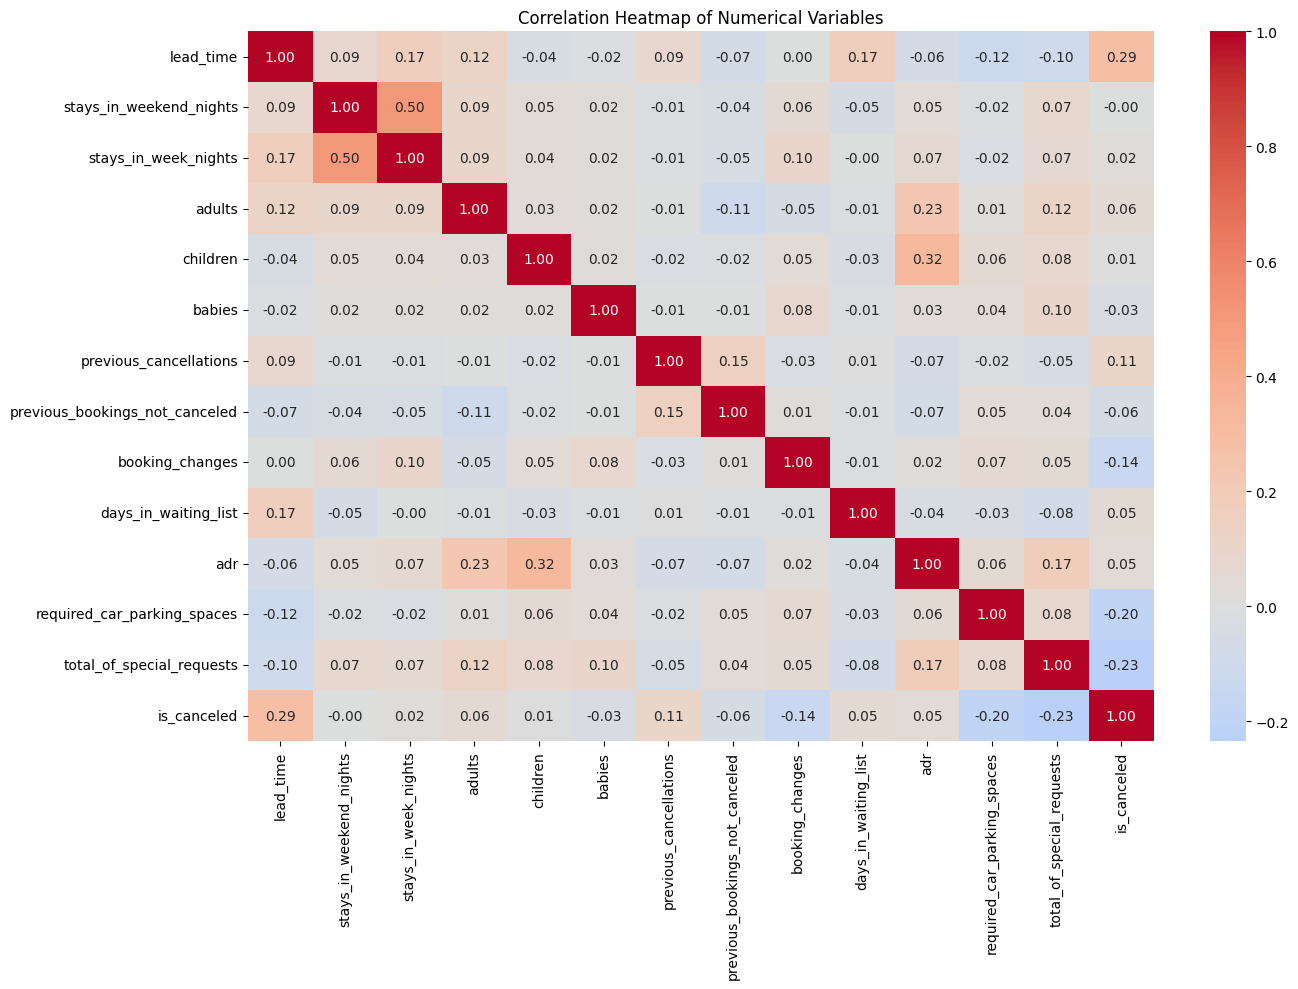

In [75]:
# Select numerical columns
numerical_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'is_canceled'
]

# Calculate correlation
corr = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

####Findings
1. Lead Time and Cancellation
There is a positive relationship between lead time and cancellation. This means bookings made far in advance are more likely to be canceled.

2. Previous Cancellations and Current Cancellation
Previous cancellations have a positive relationship with current cancellation. Guests who canceled before are more likely to cancel again.

3. Total Special Requests and Cancellation
Special requests show a negative relationship with cancellation. Guests making more special requests are generally less likely to cancel.

4. Previous Bookings and Cancellation
Previous bookings that were not canceled have a negative relationship with cancellation. This suggests that returning or loyal customers are less likely to cancel.

5. Stay Duration Variables
Weekend nights and weekday nights have a positive relationship with total stay-related variables because they both contribute to the length of the stay.

### 18. Business Questions

In this section, we use the analysis to answer **important business questions** about hotel bookings. These questions help hotels understand cancellations, customer behavior, and factors that can affect revenue.

####**1. Which hotel type has more cancellations?**
City Hotels have a **higher cancellation rate** than Resort Hotels. This means City Hotels need to focus more on reducing cancellations.



####**2. Does longer lead time increase cancellations?**
Yes. Bookings made **far in advance tend to have a higher chance of cancellation**. Hotels can use this information to create better booking policies.



####**3. Which customer type cancels the most?**
**Transient customers** have the highest cancellation rate. This shows that individual customers may be less committed to their bookings than group customers.



####**4. Which market segment has the highest cancellation rate?**
The **Undefined market segment** has the highest cancellation rate, followed by **Groups**. However, the Undefined category may contain limited or unclear customer information.



**5. Does deposit type affect cancellation?**
Yes. **Non-refundable bookings have an extremely high cancellation rate** in this dataset. This unusual result should be investigated further because it may be related to how the data records deposit types.



####**6. Do new guests cancel more than repeated guests?**
Yes. **New guests have a much higher cancellation rate** than repeated guests. This suggests that returning customers are generally more reliable.



####**7. Does changing the room type affect bookings?**
Most bookings keep the **same room type that was reserved**, while a smaller number receive a different room type.



####**8. Do canceled bookings have longer lead times?**
Yes. Canceled bookings generally have a **higher lead time** than bookings that are not canceled. This supports the finding that early bookings are more likely to be canceled.



The business analysis shows that cancellations are influenced by several factors, including hotel type, lead time, customer type, market segment, deposit type, and guest history. City Hotels and new guests have higher cancellation rates, while repeated guests are less likely to cancel. These findings can help hotels improve booking policies, identify high-risk bookings, and reduce revenue loss from cancellations.**


### 19. Key Insights

This section summarizes the most important findings from the complete analysis. These insights help us understand hotel booking patterns and the main factors related to cancellations.




####1. City Hotels have more cancellations
City Hotels have a much higher number of canceled bookings compared with Resort Hotels.



####2. Longer lead time is linked with more cancellations
Bookings made many days in advance are more likely to be canceled.



####3. New guests cancel more often
New guests have a much higher cancellation rate than repeated guests.



####4. Previous cancellation is an important warning sign
Customers who have canceled bookings before are more likely to cancel again.



####5. Deposit type has a strong effect
Non-refundable bookings show an unusually high cancellation rate in this dataset and should be investigated carefully.



####6. Repeated guests are more reliable
Returning customers have a lower cancellation rate, suggesting stronger customer loyalty.



####7. Special requests are related to lower cancellations
Bookings with more special requests generally have a lower cancellation rate.



####8. Canceled bookings usually have longer lead times
The boxplot shows that canceled bookings tend to be made further in advance.



####9. Most bookings keep the reserved room type
The majority of customers receive the same room type that they originally reserved.

# **Outliers**


###20. Outlier Detection — IQR




Outliers are observations that are unusually different from the majority of the data. In this section, the Interquartile Range (IQR) method is used to identify potential outliers in numerical variables.

The IQR method identifies observations below the lower bound or above the upper bound based on the first and third quartiles. This method is useful for detecting extreme values without assuming that the data follows a normal distribution.

Outliers identified by this method will not be removed immediately. They will be investigated further before making a final treatment decision.

####20.1 Select numerical variables

In [76]:
iqr_columns = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

iqr_columns

['lead_time',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

####20.2 Calculate IQR outliers

In [77]:
iqr_results = []

for column in iqr_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(df)) * 100

    iqr_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_percentage
    })

iqr_results_df = pd.DataFrame(iqr_results)

iqr_results_df.sort_values(
    by="Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
3,adults,2.00,2.0,0.00,2.000,2.000,29710,24.884831
8,booking_changes,0.00,0.0,0.00,0.000,0.000,18076,15.140297
4,children,0.00,0.0,0.00,0.000,0.000,8590,7.194907
11,required_car_parking_spaces,0.00,0.0,0.00,0.000,0.000,7416,6.211576
6,previous_cancellations,0.00,0.0,0.00,0.000,0.000,6484,5.430941
10,adr,69.29,126.0,56.71,-15.775,211.065,3793,3.176983
9,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,3698,3.097412
7,previous_bookings_not_canceled,0.00,0.0,0.00,0.000,0.000,3620,3.032080
2,stays_in_week_nights,1.00,3.0,2.00,-2.000,6.000,3354,2.809281
0,lead_time,18.00,160.0,142.00,-195.000,373.000,3005,2.516961


###21. Outlier Detection — Z-score




The Z-score method is used as a second approach to identify unusually high or low numerical observations. It measures how far an observation is from the mean in terms of standard deviations.

A common threshold of ±3 is used to identify potential extreme observations. Values with a Z-score greater than 3 or less than -3 are considered potential outliers.

The Z-score method is used alongside the IQR method so that the results of the two approaches can be compared.

####21.1 Calculate Z-score

In [78]:
zscore_results = []

for column in iqr_columns:
    z_scores = np.abs(stats.zscore(df[column], nan_policy="omit"))

    outlier_count = (z_scores > 3).sum()
    outlier_percentage = (outlier_count / len(df)) * 100

    zscore_results.append({
        "Feature": column,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_percentage
    })

zscore_results_df = pd.DataFrame(zscore_results)

zscore_results_df.sort_values(
    by="Outlier Count",
    ascending=False
)

,Feature,Outlier Count,Outlier %
11,required_car_parking_spaces,7416,6.211576
4,children,3729,3.123377
12,total_of_special_requests,2877,2.409750
1,stays_in_weekend_nights,2199,1.841863
9,days_in_waiting_list,1871,1.567133
2,stays_in_week_nights,1669,1.397940
8,booking_changes,1570,1.315018
0,lead_time,1454,1.217857
10,adr,1138,0.953179
7,previous_bookings_not_canceled,936,0.783985


###22. Compare Results




The IQR and Z-score methods may identify different numbers of potential outliers because they use different approaches. The IQR method is based on quartiles and is less affected by extreme values, while the Z-score method is based on the mean and standard deviation.

The results from both methods will be compared to determine which variables consistently contain potential outliers.

In [79]:
comparison = iqr_results_df[
    ["Feature", "Outlier Count", "Outlier %"]
].merge(
    zscore_results_df,
    on="Feature",
    suffixes=(" (IQR)", " (Z-score)")
)

comparison

,Feature,Outlier Count (IQR),Outlier % (IQR),Outlier Count (Z-score),Outlier % (Z-score)
0,lead_time,3005,2.516961,1454,1.217857
1,stays_in_weekend_nights,265,0.221962,2199,1.841863
2,stays_in_week_nights,3354,2.809281,1669,1.397940
3,adults,29710,24.884831,481,0.402881
4,children,8590,7.194907,3729,3.123377
5,babies,917,0.768071,917,0.768071
6,previous_cancellations,6484,5.430941,317,0.265516
7,previous_bookings_not_canceled,3620,3.032080,936,0.783985
8,booking_changes,18076,15.140297,1570,1.315018
9,days_in_waiting_list,3698,3.097412,1871,1.567133


###23. Investigate Outliers




The detected outliers were investigated by examining their distributions,
minimum and maximum values, and the most frequent values.

The IQR method identifies a relatively large number of observations as
outliers for several discrete and zero-inflated variables. These values are
not necessarily errors and may represent legitimate hotel booking behavior.

Therefore, outliers are investigated based on their business meaning rather
than being removed automatically.

In [80]:
# Investigate the distribution of variables with detected outliers

outlier_features = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

investigation = []

for col in outlier_features:
    investigation.append({
        'Feature': col,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Unique Values': df[col].nunique()
    })

investigation_df = pd.DataFrame(investigation)

investigation_df

,Feature,Min,Max,Mean,Median,Unique Values
0,lead_time,0.00,737.0,104.011416,69.000,479
1,stays_in_weekend_nights,0.00,19.0,0.927599,1.000,17
2,stays_in_week_nights,0.00,50.0,2.500302,2.000,35
3,adults,0.00,55.0,1.856403,2.000,14
4,children,0.00,10.0,0.103890,0.000,5
5,babies,0.00,10.0,0.007949,0.000,5
6,previous_cancellations,0.00,26.0,0.087118,0.000,15
7,previous_bookings_not_canceled,0.00,72.0,0.137097,0.000,73
8,booking_changes,0.00,21.0,0.221124,0.000,21
9,days_in_waiting_list,0.00,391.0,2.321149,0.000,128


#### Extreme Value Investigation

The minimum and maximum values of the numerical variables are examined to
determine whether the detected outliers represent data-entry errors or
legitimate observations.

In [81]:
# Display minimum and maximum values

for col in outlier_features:
    print(f"{col}:")
    print(f"  Minimum: {df[col].min()}")
    print(f"  Maximum: {df[col].max()}")
    print()

lead_time:
  Minimum: 0
  Maximum: 737

stays_in_weekend_nights:
  Minimum: 0
  Maximum: 19

stays_in_week_nights:
  Minimum: 0
  Maximum: 50

adults:
  Minimum: 0
  Maximum: 55

children:
  Minimum: 0.0
  Maximum: 10.0

babies:
  Minimum: 0
  Maximum: 10

previous_cancellations:
  Minimum: 0
  Maximum: 26

previous_bookings_not_canceled:
  Minimum: 0
  Maximum: 72

booking_changes:
  Minimum: 0
  Maximum: 21

days_in_waiting_list:
  Minimum: 0
  Maximum: 391

adr:
  Minimum: -6.38
  Maximum: 5400.0

required_car_parking_spaces:
  Minimum: 0
  Maximum: 8

total_of_special_requests:
  Minimum: 0
  Maximum: 5



Investigate adr specifically

adr deserves special attention because it represents Average Daily Rate and is continuous.

In [82]:
# Examine extreme ADR values

print("ADR Summary:")
print(df['adr'].describe())

print("\nHighest ADR values:")
display(
    df[['adr', 'hotel', 'is_canceled', 'adults', 'children']]
    .sort_values('adr', ascending=False)
    .head(10)
)

ADR Summary:
count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

Highest ADR values:


,adr,hotel,is_canceled,adults,children
48515,5400.00,City Hotel,1,2,0.0
111403,510.00,City Hotel,0,1,0.0
15083,508.00,Resort Hotel,0,2,0.0
103912,451.50,City Hotel,0,2,2.0
13142,450.00,Resort Hotel,1,2,0.0
13391,437.00,Resort Hotel,1,2,2.0
39155,426.25,Resort Hotel,0,2,2.0
39568,402.00,Resort Hotel,0,3,1.0
39118,397.38,Resort Hotel,0,3,2.0
13323,392.00,Resort Hotel,1,2,1.0


Investigate lead_time

In [83]:
# Examine extreme lead_time values

print("Lead Time Summary:")
print(df['lead_time'].describe())

print("\nHighest lead_time values:")
display(
    df[['lead_time', 'hotel', 'is_canceled', 'adults', 'stays_in_week_nights']]
    .sort_values('lead_time', ascending=False)
    .head(10)
)

Lead Time Summary:
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

Highest lead_time values:


,lead_time,hotel,is_canceled,adults,stays_in_week_nights
1,737,Resort Hotel,0,2,0
4182,709,Resort Hotel,0,2,20
65241,629,City Hotel,1,2,2
65240,629,City Hotel,1,2,2
65242,629,City Hotel,1,2,2
65244,629,City Hotel,1,2,2
65250,629,City Hotel,1,2,2
65249,629,City Hotel,1,2,2
65245,629,City Hotel,1,2,2
65235,629,City Hotel,1,1,1


###24. Outlier Treatment Decision



The outlier analysis shows that most detected outliers are legitimate
observations rather than data-entry errors.

The IQR method produces particularly high outlier counts for discrete and
zero-inflated variables such as `adults`, `booking_changes`, `children`,
`required_car_parking_spaces`, and `previous_cancellations`. These values
should not be removed because they represent valid hotel booking behavior.

For continuous variables such as `adr` and `lead_time`, extreme values will
be investigated rather than automatically deleted.

#### Decision

- No rows will be removed solely because they are classified as outliers.
- Discrete and zero-inflated variables will be retained.
- Legitimate extreme values will be preserved.
- Potentially erroneous values will be investigated separately.
- If outlier treatment is required for a future machine-learning model,
  techniques such as capping/winsorization may be considered for selected
  continuous variables.
- The cleaned dataset will therefore retain the original valid observations.

In [84]:
outlier_decision = pd.DataFrame({
    'Feature': outlier_features,
    'Treatment Decision': [
        'Keep - legitimate booking values',
        'Keep - legitimate booking values',
        'Keep - legitimate booking values',
        'Keep - discrete variable',
        'Keep - discrete variable',
        'Keep - discrete variable',
        'Keep - legitimate booking behavior',
        'Keep - legitimate booking behavior',
        'Keep - legitimate booking behavior',
        'Keep - legitimate booking behavior',
        'Investigate extreme values; do not remove automatically',
        'Keep - zero-inflated variable',
        'Keep - discrete variable'
    ]
})

display(outlier_decision)

,Feature,Treatment Decision
0,lead_time,Keep - legitimate booking values
1,stays_in_weekend_nights,Keep - legitimate booking values
2,stays_in_week_nights,Keep - legitimate booking values
3,adults,Keep - discrete variable
4,children,Keep - discrete variable
5,babies,Keep - discrete variable
6,previous_cancellations,Keep - legitimate booking behavior
7,previous_bookings_not_canceled,Keep - legitimate booking behavior
8,booking_changes,Keep - legitimate booking behavior
9,days_in_waiting_list,Keep - legitimate booking behavior


# **Cleaning**



###25. Data Cleaning




The dataset is cleaned systematically to improve data quality and prepare it
for further analysis and machine learning.

The cleaning process includes:

- Missing value treatment
- Duplicate removal
- Category standardization
- Data type correction
- Removal of unnecessary columns
- Final data quality validation

Legitimate extreme observations identified during the outlier analysis are
retained because they may represent valid hotel booking behavior.

In [85]:
# Creating a copy of the dataset for cleaning

df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (119390, 34)


###26. Missing Value Treatment




Missing values are examined and treated according to the meaning of each
variable.

- `children` is treated as 0 because a missing value indicates no recorded
  children in the booking.
- `country` is filled with `Unknown` because the guest's country cannot be
  reliably inferred.
- `agent` is filled with `Unknown` because a missing agent indicates that no
  agent was recorded.
- `company` contains a very large proportion of missing values and is
  evaluated separately for removal.

In [86]:
# Checking missing values before treatment

missing_before = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_before[missing_before > 0]

,0
company,112593
agent,16340
country,488
children,4


In [87]:
# Treating missing values

if 'children' in df_clean.columns:
    df_clean['children'] = df_clean['children'].fillna(0)

if 'country' in df_clean.columns:
    df_clean['country'] = df_clean['country'].fillna('Unknown')

if 'agent' in df_clean.columns:
    df_clean['agent'] = df_clean['agent'].fillna('Unknown')

if 'company' in df_clean.columns:
    df_clean['company'] = df_clean['company'].fillna('Unknown')

In [88]:
# Checking remaining missing values

missing_after = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_after[missing_after > 0]

,0


###27. Duplicate Treatment




Duplicate records can bias statistical analysis and machine learning models.

Exact duplicate rows are identified and removed while preserving the first
occurrence of each record.

In [89]:
# Checking duplicate records

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 31994


In [90]:
# Removing exact duplicate rows

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", df_clean.shape)

Shape after duplicate removal: (87396, 34)


In [91]:
# Verifying that duplicates have been removed

print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining duplicate rows: 0


###28. Category Standardization




Categorical variables are standardized to ensure consistent representation.

Leading and trailing whitespace is removed, and text categories are
standardized where appropriate.

This prevents logically identical categories from being treated as
different values during analysis.

In [92]:
# Standardizing text-based categorical columns

categorical_columns = df_clean.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [93]:
# Inspecting important categorical variables

categorical_check = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type',
    'reservation_status'
]

for col in categorical_check:
    if col in df_clean.columns:
        print(f"\n{col}:")
        print(df_clean[col].value_counts().head(20))


hotel:
hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

meal:
meal
BB           67978
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

market_segment:
market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

distribution_channel:
distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64

reserved_room_type:
reserved_room_type
A    56552
D    17398
E     6049
F     2823
G     2052
B      999
C      915
H      596
L        6
P        6
Name: count, dtype: int64

assigned_room_type:
assigned_room_type
A    46313
D    22432
E     7195
F     3627
G     2498
C     2165
B     1820
H      706
I      357
K      276
P        6
L        1
Name: count, dtype: int64

d

###29. Data Type Correction



Data types are corrected according to the meaning of each variable.

Numerical variables are converted to appropriate numeric types, while
date-related variables are converted to datetime format.

Correct data types improve memory usage, analysis, filtering, and
visualization.

In [94]:
# Converting numerical columns to numeric types

numeric_columns = [
    'is_canceled',
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [95]:
# Converting reservation_status_date to datetime

if 'reservation_status_date' in df_clean.columns:
    df_clean['reservation_status_date'] = pd.to_datetime(
        df_clean['reservation_status_date'],
        errors='coerce'
    )

In [96]:
# Display corrected data types

df_clean.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


###30. Unnecessary Column Removal



Columns are evaluated based on their usefulness, completeness, and
relevance to the analysis.

The `company` column contains a very large proportion of missing values and
provides limited analytical value for this project. Therefore, it is removed.

The `agent` column is retained because agent information may be useful for
understanding booking channels and customer acquisition patterns.

No column is removed solely because it contains unusual or extreme values.

In [97]:
# Removing unnecessary column

columns_to_remove = []

if 'company' in df_clean.columns:
    columns_to_remove.append('company')

df_clean = df_clean.drop(columns=columns_to_remove)

print("Removed columns:", columns_to_remove)
print("Current shape:", df_clean.shape)

Removed columns: ['company']
Current shape: (87396, 33)



###31. Final Data Quality Check



A final quality check is performed after all cleaning operations.

The following are verified:

- Dataset dimensions
- Missing values
- Duplicate rows
- Data types
- Numerical summary
- Categorical consistency
- Presence of infinite values

In [98]:
# Final dataset shape

print("Final dataset shape:", df_clean.shape)

Final dataset shape: (87396, 33)


In [99]:
# Final missing-value check

final_missing = df_clean.isnull().sum()

print("Total missing values:", final_missing.sum())

if final_missing.sum() > 0:
    display(final_missing[final_missing > 0])
else:
    print("No missing values found.")

Total missing values: 0
No missing values found.


In [100]:
# Final duplicate check

print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 7


In [101]:
# Check for infinite values in numerical columns

numeric_df = df_clean.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_df).sum().sum()

print("Infinite values:", infinite_values)

Infinite values: 0


In [102]:
# Final data types

display(
    pd.DataFrame({
        'Column': df_clean.columns,
        'Data Type': df_clean.dtypes.astype(str).values,
        'Missing Values': df_clean.isnull().sum().values,
        'Unique Values': df_clean.nunique().values
    })
)

,Column,Data Type,Missing Values,Unique Values
0,hotel,object,0,2
1,is_canceled,int64,0,2
2,lead_time,int64,0,479
3,arrival_date_year,int64,0,3
4,arrival_date_month,object,0,12
5,arrival_date_week_number,int64,0,53
6,arrival_date_day_of_month,int64,0,31
7,stays_in_weekend_nights,int64,0,17
8,stays_in_week_nights,int64,0,35
9,adults,int64,0,14


In [103]:
# Final numerical summary

df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
is_canceled,87396.0,0.274898,0.0,0.0,0.0,1.0,1.0,0.446466
lead_time,87396.0,79.891368,0.0,11.0,49.0,125.0,737.0,86.052325
arrival_date_year,87396.0,2016.210296,2015.0,2016.0,2016.0,2017.0,2017.0,0.686102
arrival_date_week_number,87396.0,26.838334,1.0,16.0,27.0,37.0,53.0,13.674572
arrival_date_day_of_month,87396.0,15.815541,1.0,8.0,16.0,23.0,31.0,8.835146
stays_in_weekend_nights,87396.0,1.005263,0.0,0.0,1.0,2.0,19.0,1.031921
stays_in_week_nights,87396.0,2.625395,0.0,1.0,2.0,4.0,50.0,2.053584
adults,87396.0,1.875795,0.0,2.0,2.0,2.0,55.0,0.6265
children,87396.0,0.138633,0.0,0.0,0.0,0.0,10.0,0.455871
babies,87396.0,0.010824,0.0,0.0,0.0,0.0,10.0,0.113597


#### Cleaning Summary

The hotel booking dataset was successfully cleaned through a systematic
data-cleaning process.

The following operations were performed:

1. Missing values were investigated and treated according to variable meaning.
2. Exact duplicate records were removed.
3. Categorical values were standardized.
4. Numerical and datetime data types were corrected.
5. The `company` column was removed due to its limited analytical value and
   very high proportion of missing information.
6. Legitimate outliers were retained rather than removed automatically.
7. A final data-quality check confirmed the condition of the cleaned dataset.

The resulting `df_clean` dataset is ready for exploratory data analysis,
visualization, feature engineering, and machine-learning preparation.

# **Feature Engineering**

### 32. Feature Engineering




Feature engineering is the process of creating new meaningful variables
from existing data.

Four new features are created from the hotel booking information:

1. `total_stay_nights` - total number of nights spent at the hotel.
2. `total_guests` - total number of guests included in the booking.
3. `is_family` - indicates whether the booking includes children or babies.
4. `is_long_stay` - indicates whether the booking represents a long stay.

These features provide more meaningful representations of booking behavior
and can be useful for exploratory analysis and machine learning.

###33. Feature 1 — Total Stay Nights




`total_stay_nights` combines weekday and weekend nights into a single
measure representing the total length of a guest's stay.

In [104]:
# Create total stay nights

df_clean['total_stay_nights'] = (
    df_clean['stays_in_weekend_nights'] +
    df_clean['stays_in_week_nights']
)

df_clean[['stays_in_weekend_nights',
          'stays_in_week_nights',
          'total_stay_nights']].head()

,stays_in_weekend_nights,stays_in_week_nights,total_stay_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


Checking Result

In [105]:
print("Minimum total stay nights:", df_clean['total_stay_nights'].min())
print("Maximum total stay nights:", df_clean['total_stay_nights'].max())
print("Average total stay nights:", df_clean['total_stay_nights'].mean())

Minimum total stay nights: 0
Maximum total stay nights: 69
Average total stay nights: 3.6306581536912446


###34. Feature 2 — Total Guests




`total_guests` represents the total number of people included in a booking.

It is calculated by combining adults, children, and babies.

In [106]:
# Create total guests

df_clean['total_guests'] = (
    df_clean['adults'] +
    df_clean['children'] +
    df_clean['babies']
)

df_clean[['adults',
          'children',
          'babies',
          'total_guests']].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


Checking Result

In [107]:
print("Minimum total guests:", df_clean['total_guests'].min())
print("Maximum total guests:", df_clean['total_guests'].max())
print("Average total guests:", df_clean['total_guests'].mean())

Minimum total guests: 0.0
Maximum total guests: 55.0
Average total guests: 2.025252871984988


###35. Feature 3 — Family Booking





`is_family` identifies whether a booking includes children or babies.

- `1` = family booking
- `0` = no children or babies recorded

This feature converts information about children and babies into an
interpretable binary indicator.

In [108]:
# Create family booking indicator

df_clean['is_family'] = (
    (df_clean['children'] > 0) |
    (df_clean['babies'] > 0)
).astype(int)

df_clean[['children',
          'babies',
          'is_family']].head()

,children,babies,is_family
0,0.0,0,0
1,0.0,0,0
2,0.0,0,0
3,0.0,0,0
4,0.0,0,0


Checking the Distribution

In [109]:
df_clean['is_family'].value_counts()

,count
is_family,
0,78293
1,9103


and Percentage

In [110]:
df_clean['is_family'].value_counts(normalize=True).mul(100).round(2)

,proportion
is_family,
0,89.58
1,10.42


###36. Feature 4 — Long Stay



`is_long_stay` identifies bookings with a total stay of seven nights or
more.

- `1` = stay of 7 or more nights
- `0` = stay of fewer than 7 nights

This feature can help analyze whether longer stays are associated with
different booking or cancellation behavior.

In [111]:
# Create long-stay indicator

df_clean['is_long_stay'] = (
    df_clean['total_stay_nights'] >= 7
).astype(int)

df_clean[['total_stay_nights',
          'is_long_stay']].head()

,total_stay_nights,is_long_stay
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0


Checking the Result

In [112]:
print("Long-stay bookings:")
print(df_clean['is_long_stay'].value_counts())

print("\nLong-stay percentage:")
print(
    df_clean['is_long_stay']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Long-stay bookings:
is_long_stay
0    75007
1    12389
Name: count, dtype: int64

Long-stay percentage:
is_long_stay
0    85.82
1    14.18
Name: proportion, dtype: float64


###37. Feature Validation



The newly engineered features are validated by checking:

- Data types
- Missing values
- Minimum and maximum values
- Logical consistency
- Duplicate feature calculations

The validation ensures that the engineered variables are reliable and
suitable for subsequent analysis.

In [113]:
# List engineered features

engineered_features = [
    'total_stay_nights',
    'total_guests',
    'is_family',
    'is_long_stay'
]

# Validation summary

feature_validation = pd.DataFrame({
    'Feature': engineered_features,
    'Data Type': [df_clean[col].dtype for col in engineered_features],
    'Missing Values': [df_clean[col].isnull().sum() for col in engineered_features],
    'Unique Values': [df_clean[col].nunique() for col in engineered_features],
    'Minimum': [df_clean[col].min() for col in engineered_features],
    'Maximum': [df_clean[col].max() for col in engineered_features]
})

display(feature_validation)

,Feature,Data Type,Missing Values,Unique Values,Minimum,Maximum
0,total_stay_nights,int64,0,45,0.0,69.0
1,total_guests,float64,0,15,0.0,55.0
2,is_family,int64,0,2,0.0,1.0
3,is_long_stay,int64,0,2,0.0,1.0


Checking logical consistency

In [114]:
# Validate total_stay_nights

stay_check = (
    df_clean['total_stay_nights'] ==
    (
        df_clean['stays_in_weekend_nights'] +
        df_clean['stays_in_week_nights']
    )
)

print("Total stay calculation correct:", stay_check.all())

Total stay calculation correct: True


Then validate guests

In [115]:
# Validate total_guests

guest_check = (
    df_clean['total_guests'] ==
    (
        df_clean['adults'] +
        df_clean['children'] +
        df_clean['babies']
    )
)

print("Total guests calculation correct:", guest_check.all())

Total guests calculation correct: True


Validate is_family

In [116]:
# Validate family indicator

family_check = (
    df_clean['is_family'] ==
    (
        (
            (df_clean['children'] > 0) |
            (df_clean['babies'] > 0)
        ).astype(int)
    )
)

print("Family feature calculation correct:", family_check.all())

Family feature calculation correct: True


And long stay:

In [117]:
# Validate long-stay indicator

long_stay_check = (
    df_clean['is_long_stay'] ==
    (df_clean['total_stay_nights'] >= 7).astype(int)
)

print("Long-stay feature calculation correct:", long_stay_check.all())

Long-stay feature calculation correct: True


### Feature Engineering Summary

Four new features were successfully engineered:

| Feature | Description |
|---|---|
| `total_stay_nights` | Total number of weekend and weekday nights |
| `total_guests` | Total adults, children, and babies |
| `is_family` | Indicates whether children or babies are present |
| `is_long_stay` | Indicates stays of seven or more nights |

All engineered features were validated for missing values, data types, value
ranges, and logical consistency.

The new features are retained in `df_clean` for subsequent exploratory
analysis and modeling.

#**Final Dataset**




###38. Final Dataset Inspection



After completing data cleaning and feature engineering, the final dataset is inspected to verify its structure, dimensions, and sample records.

In [118]:
# Final dataset shape
print("Final Dataset Shape:", df_clean.shape)

# Display first 5 rows
display(df_clean.head())

# Display last 5 rows
display(df_clean.tail())

# Dataset information
df_clean.info()

Final Dataset Shape: (87396, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,room_type_changed,total_guests,is_family,is_long_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,False,2.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,False,2.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,True,1.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,False,1.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,False,2.0,0,0


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,room_type_changed,total_guests,is_family,is_long_stay
87391,City Hotel,0,23,2017,August,35,30,2,5,2,...,96.14,0,0,Check-Out,2017-09-06,7,False,2.0,0,1
87392,City Hotel,0,102,2017,August,35,31,2,5,3,...,225.43,0,2,Check-Out,2017-09-07,7,False,3.0,0,1
87393,City Hotel,0,34,2017,August,35,31,2,5,2,...,157.71,0,4,Check-Out,2017-09-07,7,False,2.0,0,1
87394,City Hotel,0,109,2017,August,35,31,2,5,2,...,104.40,0,0,Check-Out,2017-09-07,7,False,2.0,0,1
87395,City Hotel,0,205,2017,August,35,29,2,7,2,...,151.20,0,2,Check-Out,2017-09-07,9,False,2.0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87396 non-null  object        
 1   is_canceled                     87396 non-null  int64         
 2   lead_time                       87396 non-null  int64         
 3   arrival_date_year               87396 non-null  int64         
 4   arrival_date_month              87396 non-null  object        
 5   arrival_date_week_number        87396 non-null  int64         
 6   arrival_date_day_of_month       87396 non-null  int64         
 7   stays_in_weekend_nights         87396 non-null  int64         
 8   stays_in_week_nights            87396 non-null  int64         
 9   adults                          87396 non-null  int64         
 10  children                        87396 non-null  float64       
 11  ba

###39. Final Missing Values




A final missing-value check is performed to ensure that no unintended missing values remain in the cleaned dataset.

In [119]:
# Check missing values
final_missing = df_clean.isnull().sum()

# Display only columns containing missing values
display(final_missing[final_missing > 0])

# Total missing values
print("Total Missing Values:", df_clean.isnull().sum().sum())

,0


Total Missing Values: 0


###40. Final Duplicate Check




The final dataset is checked for duplicate records to ensure that duplicate observations have been removed.

In [120]:
# Count duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Final Duplicate Rows:", duplicate_count)

if duplicate_count == 0:
    print("✓ No duplicate rows remain in the final dataset.")
else:
    print("⚠ Duplicate rows still exist.")

Final Duplicate Rows: 7
⚠ Duplicate rows still exist.


we have got duplicate rows, so

Firstly, inspect the 7 duplicates

In [122]:
duplicate_rows = df_clean[df_clean.duplicated(keep=False)]

print("Duplicate rows:", len(duplicate_rows))

display(duplicate_rows)

Duplicate rows: 14


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,room_type_changed,total_guests,is_family,is_long_stay
2597,Resort Hotel,0,1,2015,November,45,4,0,1,1,...,35.0,0,0,Check-Out,2015-11-05,1,False,1.0,0,0
14130,Resort Hotel,0,1,2015,November,45,4,0,1,1,...,35.0,0,0,Check-Out,2015-11-05,1,False,1.0,0,0
14364,Resort Hotel,0,0,2015,November,47,18,0,1,1,...,38.0,0,0,Check-Out,2015-11-19,1,True,1.0,0,0
14365,Resort Hotel,0,0,2015,November,47,18,0,1,1,...,38.0,0,0,Check-Out,2015-11-19,1,True,1.0,0,0
20878,Resort Hotel,0,9,2016,July,28,4,1,0,2,...,189.0,0,0,Check-Out,2016-07-05,1,True,2.0,0,0
20882,Resort Hotel,0,9,2016,July,28,4,1,0,2,...,189.0,0,0,Check-Out,2016-07-05,1,True,2.0,0,0
25898,Resort Hotel,0,2,2016,December,51,14,0,1,1,...,30.0,0,0,Check-Out,2016-12-15,1,True,1.0,0,0
25910,Resort Hotel,0,2,2016,December,51,14,0,1,1,...,30.0,0,0,Check-Out,2016-12-15,1,True,1.0,0,0
27891,Resort Hotel,0,0,2017,February,8,21,0,1,1,...,35.0,0,0,Check-Out,2017-02-22,1,False,1.0,0,0
27900,Resort Hotel,0,0,2017,February,8,21,0,1,1,...,35.0,0,0,Check-Out,2017-02-22,1,False,1.0,0,0


In [123]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

In [124]:
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining duplicate rows: 0


In [125]:
print("Final shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Final shape: (87389, 36)
Missing values: 0
Duplicate rows: 0


###41. Final Data Types




The data types of all variables are reviewed to confirm that numerical, categorical, and other variables have appropriate data types.

In [121]:
# Display final data types
final_dtypes = pd.DataFrame({
    "Feature": df_clean.columns,
    "Data Type": df_clean.dtypes.astype(str).values
})

display(final_dtypes)

,Feature,Data Type
0,hotel,object
1,is_canceled,int64
2,lead_time,int64
3,arrival_date_year,int64
4,arrival_date_month,object
5,arrival_date_week_number,int64
6,arrival_date_day_of_month,int64
7,stays_in_weekend_nights,int64
8,stays_in_week_nights,int64
9,adults,int64


###42. Export Clean Dataset



The final cleaned and feature-engineered dataset is exported as a CSV file for further analysis, visualization, and machine learning.

In [126]:
# Export final cleaned dataset
output_file = "hotel_bookings_cleaned.csv"

df_clean.to_csv(output_file, index=False)

print(f"✓ Clean dataset exported successfully: {output_file}")

✓ Clean dataset exported successfully: hotel_bookings_cleaned.csv


In [127]:
# Verify exported dataset
import os

if os.path.exists(output_file):
    print(f"✓ File exists: {output_file}")
    print(f"File size: {os.path.getsize(output_file) / 1024:.2f} KB")
else:
    print("⚠ Export failed.")

✓ File exists: hotel_bookings_cleaned.csv
File size: 13413.93 KB
